# EE2211 Cheat Sheet (Tutorials 2–9)

All cells are runnable. Covers patterns from Tutorials 2–9, homework datasets, and midterm exam types.

**Contents**
1. NumPy — Array Creation
2. NumPy — Array Properties
3. NumPy — Indexing & Slicing
4. NumPy — Reshaping & Stacking
5. NumPy — Element-wise Math
6. NumPy — Matrix Multiplication
7. NumPy — Linear Algebra
8. NumPy — Statistics
9. NumPy — ML-Specific Patterns
10. Pandas — Loading & Inspecting
11. Pandas — Selecting Data
12. Pandas — Filtering
13. Pandas — Data Cleaning
14. Pandas — Column Operations
15. Pandas — Aggregation
16. Pandas — Pandas → NumPy
17. Pandas — Visualization
18. Probability — Gaussian Distribution
19. Probability — Discrete / Dice
20. Core Tool 4.1 — `solveLE`
21. Core Tool 4.2 — `polyTx` + `solvePR`
22. Core Tool 4.3 — Pearson Correlation (Tut 7)
23. Core Tool 4.4 — Polynomial Order Sweep (Tut 7)
24. Workflow 1 — System Analysis (Tut 4)
25. Workflow 2 — Linear Regression (Tut 5)
26. Workflow 3 — Polynomial Regression (Tut 6)
27. Workflow 4 — Ridge Regression (Tut 6)
28. Workflow 5 — Data Cleaning Pipeline (Tut 2)
29. Workflow 6 — Binary Classification (Tut 6)
30. Workflow 7 — Multi-Class Classification (Tut 6)
31. Workflow 8 — EDA with Scatter Matrix (Tut 2)
32. Workflow 9 — Duplicate Data Comparison (Tut 5)
33. Workflow 10 — Multi-Feature Polynomial (Tut 6)
34. Workflow 11 — Feature Selection via Pearson (Tut 7 Q1)
35. Workflow 12 — Polynomial Order Sweep, no reg (Tut 7 Q2a)
36. Workflow 13 — Ridge Sweep Comparison λ=1 (Tut 7 Q2b)
37. Quick Reference Card

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.linalg import inv, matrix_rank, det

print('NumPy  :', np.__version__)
print('Pandas :', pd.__version__)

NumPy  : 2.4.2
Pandas : 2.3.3


---
## Part 1 — NumPy
### 1.2 Array Creation

In [2]:
v = np.array([1, 2, 3, 4])               # 1D, shape (4,)
X = np.array([[1, 2, 3], [4, 5, 6]])     # 2D, shape (2, 3)
Z = np.zeros((3, 2))
O = np.ones((2, 4))
I = np.eye(3)                             # 3×3 identity
x_lin = np.linspace(0, 10, 5)            # [0, 2.5, 5, 7.5, 10]
x_rng = np.arange(0, 10, 2)             # [0, 2, 4, 6, 8]
R_norm = np.random.randn(3, 3)           # standard normal

print('X     :\n', X)
print('I     :\n', I)
print('linspace:', x_lin)

X     :
 [[1 2 3]
 [4 5 6]]
I     :
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
linspace: [ 0.   2.5  5.   7.5 10. ]


---
### 1.3 Array Properties

In [3]:
X = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])

print('shape :', X.shape)    # (3, 3)
print('ndim  :', X.ndim)     # 2
print('dtype :', X.dtype)
print('size  :', X.size)     # 9

N, M = X.shape
print(f'N={N} rows (samples), M={M} cols (features)')

shape : (3, 3)
ndim  : 2
dtype : int64
size  : 9
N=3 rows (samples), M=3 cols (features)


---
### 1.4 Indexing & Slicing

In [4]:
A = np.array([[10, 20, 30], [40, 50, 60], [70, 80, 90]])

print('A[0, 0]   :', A[0, 0])          # 10
print('A[1, :]   :', A[1, :])          # [40 50 60]  row 1
print('A[:, 2]   :', A[:, 2])          # [30 60 90]  col 2
print('A[0:2, :]:\n', A[0:2, :])       # rows 0-1
print('A[-1, :]  :', A[-1, :])         # last row
print('A > 50    :', A[A > 50])        # [60 70 80 90]
print('where A>50:\n', np.where(A > 50, 1, 0))

A[0, 0]   : 10
A[1, :]   : [40 50 60]
A[:, 2]   : [30 60 90]
A[0:2, :]:
 [[10 20 30]
 [40 50 60]]
A[-1, :]  : [70 80 90]
A > 50    : [60 70 80 90]
where A>50:
 [[0 0 0]
 [0 0 1]
 [1 1 1]]


---
### 1.5 Reshaping & Stacking

In [5]:
x = np.array([1, 2, 3, 4, 5, 6])
print('reshape(2,3):\n', x.reshape(2, 3))
print('reshape(-1,1):\n', x.reshape(-1, 1))  # column vector (6,1)

A = np.ones((3, 2))
B = np.zeros((3, 1))
print('hstack shape:', np.hstack([A, B]).shape)  # (3, 3)
print('vstack shape:', np.vstack([A, A]).shape)  # (6, 2)

# np.append — used for augmented matrix [X | y]
X = np.array([[1, 2], [3, 4]])
y = np.array([[5], [6]])
print('augmented [X|y]:\n', np.append(X, y, axis=1))

reshape(2,3):
 [[1 2 3]
 [4 5 6]]
reshape(-1,1):
 [[1]
 [2]
 [3]
 [4]
 [5]
 [6]]
hstack shape: (3, 3)
vstack shape: (6, 2)
augmented [X|y]:
 [[1 2 5]
 [3 4 6]]


---
### 1.6 Element-wise Math & Broadcasting

In [6]:
X = np.array([[1.0, 2.0], [3.0, 4.0]])

print('X + 10  :\n', X + 10)
print('X * 2   :\n', X * 2)
print('np.square:\n', np.square(X))
print('np.sqrt :\n', np.sqrt(X))
print('np.exp  :\n', np.exp(X))
print('np.log  :\n', np.log(X))

# Broadcasting
mu = np.mean(X, axis=0)
print('\nX - mu (broadcast):\n', X - mu)

X + 10  :
 [[11. 12.]
 [13. 14.]]
X * 2   :
 [[2. 4.]
 [6. 8.]]
np.square:
 [[ 1.  4.]
 [ 9. 16.]]
np.sqrt :
 [[1.         1.41421356]
 [1.73205081 2.        ]]
np.exp  :
 [[ 2.71828183  7.3890561 ]
 [20.08553692 54.59815003]]
np.log  :
 [[0.         0.69314718]
 [1.09861229 1.38629436]]

X - mu (broadcast):
 [[-1. -1.]
 [ 1.  1.]]


---
### 1.7 Matrix Multiplication

In [7]:
A = np.array([[1, 2], [3, 4], [5, 6]])   # (3, 2)
B = np.array([[7, 8, 9], [10, 11, 12]])  # (2, 3)

print('A @ B:\n', A @ B)          # matrix product (3,3)
print('same as np.dot?', np.allclose(A @ B, np.dot(A, B)))

X = np.array([[1, 2], [3, 4]])
print('\nX * X (element-wise):\n', X * X)
print('X @ X (matrix mult) :\n', X @ X)

A @ B:
 [[ 27  30  33]
 [ 61  68  75]
 [ 95 106 117]]
same as np.dot? True

X * X (element-wise):
 [[ 1  4]
 [ 9 16]]
X @ X (matrix mult) :
 [[ 7 10]
 [15 22]]


---
### 1.8 Linear Algebra (`np.linalg`)

In [8]:
from numpy.linalg import inv, matrix_rank, det

A = np.array([[2.0, 1.0], [5.0, 3.0]])
b = np.array([[8.0], [21.0]])

print('det(A)  :', det(A))           # 1.0
print('rank(A) :', matrix_rank(A))   # 2
print('inv(A)  :\n', inv(A))
print('solve   :', np.linalg.solve(A, b).ravel())  # [3. 2.]

# Augmented matrix rank check — system consistency
X = np.array([[1, 2], [2, 4], [1, -1]])
y = np.array([[0], [0.1], [1]])
X_aug = np.append(X, y, axis=1)
print('\nrank(X)  =', matrix_rank(X))
print('rank(X~) =', matrix_rank(X_aug))
# equal → consistent; different → no solution

det(A)  : 1.0000000000000002
rank(A) : 2
inv(A)  :
 [[ 3. -1.]
 [-5.  2.]]
solve   : [3. 2.]

rank(X)  = 2
rank(X~) = 3


---
### 1.9 Statistics

In [9]:
X = np.array([[2.0, 4.0, 6.0], [1.0, 3.0, 5.0], [3.0, 5.0, 7.0]])

print('mean (all)      :', np.mean(X))
print('mean (col-wise) :', np.mean(X, axis=0))
print('mean (row-wise) :', np.mean(X, axis=1))
print('std  (col-wise) :', np.std(X, axis=0))
print('sum  (all)      :', np.sum(X))
print('min / max       :', np.min(X), '/', np.max(X))
print('argmin / argmax :', np.argmin(X), '/', np.argmax(X))

mean (all)      : 4.0
mean (col-wise) : [2. 4. 6.]
mean (row-wise) : [4. 3. 5.]
std  (col-wise) : [0.81649658 0.81649658 0.81649658]
sum  (all)      : 36.0
min / max       : 1.0 / 7.0
argmin / argmax : 3 / 8


---
### 1.10 ML-Specific NumPy Patterns

In [10]:
np.random.seed(42)
X = np.random.randn(8, 3)
y = np.random.randn(8, 1)
N, M = X.shape

# Add bias column
bias = np.ones((N, 1))
X_b = np.hstack((bias, X))     # shape (8, 4)
print('X_b shape:', X_b.shape)

# Z-score standardization
mu    = np.mean(X, axis=0)
sigma = np.std(X, axis=0)
X_norm = (X - mu) / sigma
print('Norm mean:', np.mean(X_norm, axis=0).round(10))

# Train/test split
split = int(0.8 * N)
X_train, X_test = X_b[:split], X_b[split:]
y_train, y_test = y[:split],   y[split:]

# MSE
w = inv(X_train.T @ X_train) @ X_train.T @ y_train
y_pred = X_test @ w
mse = np.mean((y_pred - y_test) ** 2)
print(f'Test MSE: {mse:.4f}')

X_b shape: (8, 4)
Norm mean: [-0.  0. -0.]
Test MSE: 6.6892


---
## Part 2 — Pandas
### 2.1 Loading & Inspecting

In [11]:
data = {
    'age':    [25, 32, 47, 19, 55, 38],
    'income': [40000, 62000, 85000, 28000, 110000, 71000],
    'score':  [88, 75, 91, 60, 95, 82],
    'grade':  ['B', 'C', 'A', 'D', 'A', 'B'],
}
df = pd.DataFrame(data)
# In exam: df = pd.read_csv('government-expenditure-on-education.csv')

print(df.head(3))
print('\nshape   :', df.shape)
print('columns :', df.columns.tolist())
df.info()
print(df.describe())

   age  income  score grade
0   25   40000     88     B
1   32   62000     75     C
2   47   85000     91     A

shape   : (6, 4)
columns : ['age', 'income', 'score', 'grade']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   age     6 non-null      int64 
 1   income  6 non-null      int64 
 2   score   6 non-null      int64 
 3   grade   6 non-null      object
dtypes: int64(3), object(1)
memory usage: 324.0+ bytes
             age       income      score
count   6.000000       6.0000   6.000000
mean   36.000000   66000.0000  81.833333
std    13.505554   29859.6718  12.797135
min    19.000000   28000.0000  60.000000
25%    26.750000   45500.0000  76.750000
50%    35.000000   66500.0000  85.000000
75%    44.750000   81500.0000  90.250000
max    55.000000  110000.0000  95.000000


---
### 2.2 Selecting Data

In [12]:
print(df['age'])                   # single column → Series
print(df[['age', 'score']])        # multiple columns → DataFrame
print(df.iloc[0:3, 0:2])          # by position
print(df.iloc[:, -1])             # last column
print(df.loc[0:2, 'age'])         # by label

0    25
1    32
2    47
3    19
4    55
5    38
Name: age, dtype: int64
   age  score
0   25     88
1   32     75
2   47     91
3   19     60
4   55     95
5   38     82
   age  income
0   25   40000
1   32   62000
2   47   85000
0    B
1    C
2    A
3    D
4    A
5    B
Name: grade, dtype: object
0    25
1    32
2    47
Name: age, dtype: int64


---
### 2.3 Filtering (Boolean Indexing)

In [13]:
print(df[df['age'] > 30])
print(df[(df['age'] > 30) & (df['score'] > 80)])
print(df[(df['age'] < 25) | (df['score'] > 90)])
print(df[~(df['grade'] == 'A')])
print(df[df['grade'].isin(['A', 'B'])])

   age  income  score grade
1   32   62000     75     C
2   47   85000     91     A
4   55  110000     95     A
5   38   71000     82     B
   age  income  score grade
2   47   85000     91     A
4   55  110000     95     A
5   38   71000     82     B
   age  income  score grade
2   47   85000     91     A
3   19   28000     60     D
4   55  110000     95     A
   age  income  score grade
0   25   40000     88     B
1   32   62000     75     C
3   19   28000     60     D
5   38   71000     82     B
   age  income  score grade
0   25   40000     88     B
2   47   85000     91     A
4   55  110000     95     A
5   38   71000     82     B


---
### 2.4 Data Cleaning

In [14]:
dirty = pd.DataFrame({
    'Glucose':       [148, 0, 183, 0, 137],
    'BloodPressure': [72, 66, 0, 40, 70],
    'BMI':           [33.6, 0.0, 23.3, 35.4, 43.1],
    'Outcome':       [1, 0, 1, 0, 1],
})

# Check zeros (Tutorial 2 / Pima pattern)
print('Zero counts:')
print((dirty[['Glucose', 'BloodPressure', 'BMI']] == 0).sum())

# Replace zeros with NaN
suspect = ['Glucose', 'BloodPressure', 'BMI']
dirty[suspect] = dirty[suspect].replace(0, np.nan)
print('\nNull counts after replace:')
print(dirty.isnull().sum())

# Drop rows with NaN
clean = dirty.dropna()
print(f'\nRows after dropna: {len(clean)}')

# Alternative: fill with column mean
# dirty.fillna(dirty.mean(), inplace=True)

Zero counts:
Glucose          2
BloodPressure    1
BMI              1
dtype: int64

Null counts after replace:
Glucose          2
BloodPressure    1
BMI              1
Outcome          0
dtype: int64

Rows after dropna: 2


---
### 2.5 Column Operations

In [15]:
df2 = df.copy()
df2.drop('grade', axis=1, inplace=True)
df2.rename(columns={'score': 'test_score'}, inplace=True)
df2['log_income'] = np.log(df2['income'])
df2.reset_index(drop=True, inplace=True)
print(df2)

   age  income  test_score  log_income
0   25   40000          88   10.596635
1   32   62000          75   11.034890
2   47   85000          91   11.350407
3   19   28000          60   10.239960
4   55  110000          95   11.608236
5   38   71000          82   11.170435


---
### 2.6 Aggregation

In [16]:
print(df['grade'].value_counts())
print(df['grade'].unique())
print(df['grade'].nunique())
print(df.groupby('grade').mean(numeric_only=True))
print(df.groupby('grade')['score'].mean())

grade
B    2
A    2
C    1
D    1
Name: count, dtype: int64
['B' 'C' 'A' 'D']
4
        age   income  score
grade                      
A      51.0  97500.0   93.0
B      31.5  55500.0   85.0
C      32.0  62000.0   75.0
D      19.0  28000.0   60.0
grade
A    93.0
B    85.0
C    75.0
D    60.0
Name: score, dtype: float64


---
### 2.7 Pandas → NumPy (exam pattern)

In [17]:
# Named columns
X = np.array(df.drop('grade', axis=1).select_dtypes(include='number'))  # (N, M)
y = np.array(df['score']).reshape(-1, 1)                                 # (N, 1)
print('X shape:', X.shape, '  y shape:', y.shape)

# Unnamed CSV headers (column indices)
# X = np.array(df.iloc[:, :-1])
# y = np.array(df.iloc[:, -1]).reshape(-1, 1)

X shape: (6, 3)   y shape: (6, 1)


---
### 2.8 Visualization

Tutorial 2 Q1: line plot. Tutorial 2 Q2: multi-series (bus types). Tutorial 2 Q3: scatter matrix.

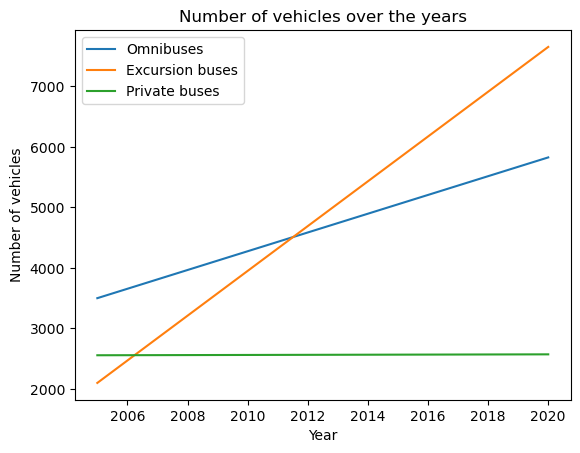

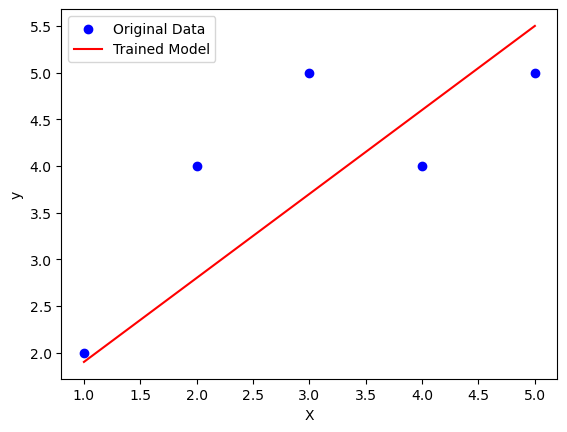

In [18]:
import matplotlib.pyplot as plt

# --- Tutorial 2 Q2: multi-series line plot (bus types) ---
# Simulate long-format DataFrame
years = list(range(2005, 2021))
records = []
for yr in years:
    records += [
        {'year': yr, 'type': 'Omnibuses',       'number': 3500 + (yr-2005)*155},
        {'year': yr, 'type': 'Excursion buses',  'number': 2100 + (yr-2005)*370},
        {'year': yr, 'type': 'Private buses',    'number': 2557 + (yr-2005)*1},
    ]
df_bus = pd.DataFrame(records)

# Tutorial 2 exact style: .loc + .index
val1 = df_bus.loc[df_bus['type'] == 'Omnibuses'].index
val2 = df_bus.loc[df_bus['type'] == 'Excursion buses'].index
val3 = df_bus.loc[df_bus['type'] == 'Private buses'].index

List1 = df_bus.loc[val1]
List2 = df_bus.loc[val2]
List3 = df_bus.loc[val3]

plt.plot(List1['year'], List1['number'], label='Omnibuses')
plt.plot(List2['year'], List2['number'], label='Excursion buses')
plt.plot(List3['year'], List3['number'], label='Private buses')
plt.xlabel('Year')
plt.ylabel('Number of vehicles')
plt.title('Number of vehicles over the years')
plt.legend()
plt.show()

# --- Scatter + fitted line ---
X_plot = np.array([[1],[2],[3],[4],[5]])
y_plot = np.array([[2],[4],[5],[4],[5]])
plt.scatter(X_plot, y_plot, color='blue', label='Original Data', marker='o')
plt.plot(X_plot, X_plot * 0.9 + 1, color='red', label='Trained Model')
plt.xlabel('X'); plt.ylabel('y'); plt.legend(); plt.show()

---
## Part 3 — Probability (Tutorial 3)
### 3.1 Gaussian / Normal Distribution

Use-case: **resistor quality control** — check if production batch falls within spec range (Tutorial 3 Q5).

In [19]:
from scipy import stats

# X ~ N(mu, sigma)
# Tutorial 3 Q5: resistor in [28Ω, 33Ω], mu=30, sigma=1.8
mu, sigma = 30, 1.8
prob = stats.norm.cdf(33, mu, sigma) - stats.norm.cdf(28, mu, sigma)
print(f'P(28 ≤ X ≤ 33) = {prob:.4f}')

# P(X > a)
a = 31
prob_gt = 1 - stats.norm.cdf(a, mu, sigma)
print(f'P(X > {a})     = {prob_gt:.4f}')

# P(X < a)
prob_lt = stats.norm.cdf(a, mu, sigma)
print(f'P(X < {a})     = {prob_lt:.4f}')

P(28 ≤ X ≤ 33) = 0.8189
P(X > 31)     = 0.2893
P(X < 31)     = 0.7107


---
### 3.2 Discrete Probability (Tutorial 3 Q4)

Use-case: **dice rolling** — build the PMF of the sum of two dice.

In [20]:
from collections import defaultdict
import numpy as np

# Build sum dictionary: (i,j) -> i+j
d = {(i, j): i + j for i in range(1, 7) for j in range(1, 7)}
print('(3,4) ->', d[(3, 4)])   # 7

# Invert: group pairs by their sum value
dinv = defaultdict(list)
for k, v in d.items():
    dinv[v].append(k)

# PMF: P(X = x) = count / 36
X_pmf = {x: len(pairs) / 36. for x, pairs in dinv.items()}
print('PMF:', X_pmf)

# P(half the product of three dice > their sum)
d3 = {(i, j, k): ((i*j*k)/2 > i+j+k)
      for i in range(1, 7) for j in range(1, 7) for k in range(1, 7)}
prob = sum(d3.values()) / 216
print(f'P(product/2 > sum) = {prob:.4f}')

(3,4) -> 7
PMF: {2: 0.027777777777777776, 3: 0.05555555555555555, 4: 0.08333333333333333, 5: 0.1111111111111111, 6: 0.1388888888888889, 7: 0.16666666666666666, 8: 0.1388888888888889, 9: 0.1111111111111111, 10: 0.08333333333333333, 11: 0.05555555555555555, 12: 0.027777777777777776}
P(product/2 > sum) = 0.6296


---
## Part 4 — Core ML Tools
### 4.1 `solveLE` — LE Solving Tool

Automatically handles **even / over / under-determined** linear systems.  
Source: Tutorial 4–6 notebooks (Ni Qingqing @ NUS ECE).

In [21]:
import numpy as np
from numpy.linalg import inv, matrix_rank

def det_checker(X):
    m, d = X.shape
    if m == d:   return "even"
    elif m > d:  return "over"
    else:        return "under"

def RC_checker(X, y):
    X_aug  = np.append(X, y, axis=1)
    rankX  = matrix_rank(X)
    rankX_ = matrix_rank(X_aug)
    d = X.shape[1]
    if rankX == rankX_:
        RC = 1 if rankX == d else 3
    else:
        RC = 2
    return RC, rankX, rankX_

def evenSolver(X, y):
    RC, _, _ = RC_checker(X, y)
    if RC == 1:   return inv(X) @ y, "Unique solution."
    elif RC == 2: return None, "No solution."
    else:         return None, "Infinitely many solutions."

def overSolver(X, y):
    RC, _, _ = RC_checker(X, y)
    if RC == 1:   return inv(X.T @ X) @ X.T @ y, "Unique solution."
    elif RC == 3: return None, "Infinitely many solutions."
    else:         return inv(X.T @ X) @ X.T @ y, "No exact sol, least square approx."

def underSolver(X, y):
    RC, _, _ = RC_checker(X, y)
    if RC == 2:   return None, "No solution."
    else:         return X.T @ inv(X @ X.T) @ y, "No exact sol, least norm approx."

def solveLE(X, y):
    det = det_checker(X)
    if det == "even":   w, ans = evenSolver(X, y)
    elif det == "over": w, ans = overSolver(X, y)
    else:               w, ans = underSolver(X, y)
    print(ans, "\nw =", w)
    return w

# --- Quick diagnostic ---
X = np.array([[1, 3], [1, 4], [1, 5], [1, 6], [1, 7]])
y = np.array([[5], [4], [3], [2], [1]])

print("System type:", det_checker(X))
RC, rX, rX_ = RC_checker(X, y)
print(f"rank(X)={rX}, rank(X~)={rX_}, case={RC}")
w = solveLE(X, y)

System type: over
rank(X)=2, rank(X~)=2, case=1
Unique solution. 
w = [[ 8.]
 [-1.]]


---
### 4.2 `polyTx` + `solvePR` — Polynomial Transformer + Solver

Source: Tutorial 6 notebook.

In [22]:
from sklearn.preprocessing import PolynomialFeatures
from numpy.linalg import inv
import numpy as np

def polyTx(X, order):
    """Polynomial feature matrix with bias column. Shape: (N, order+1)."""
    return PolynomialFeatures(order).fit_transform(X)

def solvePR(P, y, ridge=False, lamb=0.01):
    """Solve polynomial regression. Auto primal (N>M) or dual (N<M)."""
    if ridge:
        if P.shape[0] > P.shape[1]:   # Primal
            w = inv(P.T @ P + lamb * np.eye(P.shape[1])) @ P.T @ y
        else:                          # Dual
            w = P.T @ inv(P @ P.T + lamb * np.eye(P.shape[0])) @ y
    else:
        if P.shape[0] > P.shape[1]:   # Primal
            w = inv(P.T @ P) @ P.T @ y
        else:                          # Dual
            w = P.T @ inv(P @ P.T) @ y
    return w

def solveLE_Ridge(X, y, lamb=0.01):
    """Linear regression with Ridge. X must already include bias column."""
    return solvePR(X, y, ridge=True, lamb=lamb)

# Quick test
X_test_poly = np.array([[-10], [-8], [-3], [-1], [2], [8]])
y_test_poly = np.array([[5], [5], [4], [3], [2], [2]])
P = polyTx(X_test_poly, 3)
print('P shape:', P.shape)  # (6, 4): [1, x, x^2, x^3]
w = solvePR(P, y_test_poly)
print('w:', w.ravel())

P shape: (6, 4)
w: [ 2.68935636 -0.37722517  0.01343815  0.00285772]


---
## Part 5 — ML Workflows
### Workflow 1 — System Analysis (Tutorial 4)

Use-case: determine if Xw = y has a unique / approximate / no solution.

In [23]:
import numpy as np
from numpy.linalg import inv, matrix_rank

# --- Even-determined: unique solution ---
X = np.array([[1, 1], [3, 4]])
y = np.array([[0], [1]])

X_aug = np.append(X, y, axis=1)
print('rank(X) =', matrix_rank(X), '  rank(X~) =', matrix_rank(X_aug))
w = inv(X) @ y
print('w =', w.ravel())
print('Verify X@w:', (X @ w).ravel())   # should equal y

# --- Overdetermined (N > M): least-squares ---
# LEFT pseudo-inverse: w* = (X^T X)^{-1} X^T y
X = np.array([[1, 2], [2, 4], [1, -1]])
y = np.array([[0], [0.1], [1]])
w = inv(X.T @ X) @ X.T @ y
print('\nLeast-squares w =', w.ravel())
print('X@w (approx y)   :', (X @ w).ravel())

# --- Underdetermined (N < M): minimum-norm ---
# RIGHT pseudo-inverse: w* = X^T (X X^T)^{-1} y
X = np.array([[1, 0, 1, 0], [1, -1, 1, -1], [1, 1, 0, 0]])
y = np.array([[1], [0], [1]])
w = X.T @ inv(X @ X.T) @ y
print('\nLeast-norm w    =', w.ravel())
print('X@w (should==y) :', (X @ w).ravel())

rank(X) = 2   rank(X~) = 2
w = [-1.  1.]
Verify X@w: [0. 1.]

Least-squares w = [ 0.68 -0.32]
X@w (approx y)   : [0.04 0.08 1.  ]

Least-norm w    = [0.5 0.5 0.5 0.5]
X@w (should==y) : [1. 0. 1.]


---
### Workflow 2 — Linear Regression (Tutorial 5)

Use-case: **predict books sold** from number of registered students.

No exact sol, least square approx. 
w = [[9.3       ]
 [0.67272727]]
Predictions: [29.48181818 12.66363636]
No exact sol, least square approx. 
w = [[0.94987959]]


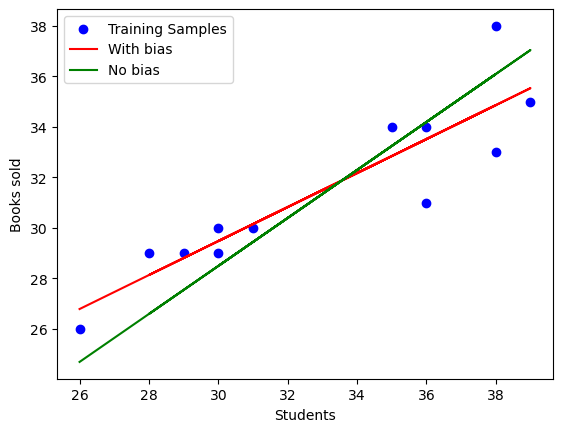

In [24]:
import numpy as np
import matplotlib.pyplot as plt

X = np.array([[36],[28],[35],[39],[30],[30],[31],[38],[36],[38],[29],[26]])
y = np.array([[31],[29],[34],[35],[29],[30],[30],[38],[34],[33],[29],[26]])

# --- With bias ---
bias = np.ones((X.shape[0], 1))
X_b  = np.hstack((bias, X))         # [1, x]
w    = solveLE(X_b, y)              # w = [w0_bias, w1_slope]

# Predict for new inputs
X_test   = np.array([[30], [5]])
X_test_b = np.hstack((np.ones((X_test.shape[0], 1)), X_test))
y_pred   = X_test_b @ w
print('Predictions:', y_pred.ravel())

# --- Without bias ---
w_nb = solveLE(X, y)

# --- Plot both ---
plt.scatter(X, y, color='blue', label='Training Samples', marker='o')
plt.plot(X, X_b @ w,    color='red',   label='With bias')
plt.plot(X, X   @ w_nb, color='green', label='No bias')
plt.xlabel('Students'); plt.ylabel('Books sold'); plt.legend(); plt.show()

In [25]:
# Multi-output regression (Tutorial 5 Q9) — multiple targets simultaneously
X = np.array([[3,-1,0],[5,1,2],[9,-1,3],[-6,7,2],[3,-2,0]])
Y = np.array([[1,-1],[-1,0],[1,2],[0,3],[1,-2]])   # two targets

bias = np.ones((X.shape[0], 1))
X_b  = np.hstack((bias, X))
W    = solveLE(X_b, Y)             # W shape (M+1, 2)

x_new   = np.array([[8, 0, 2]])
x_new_b = np.hstack((np.ones((1, 1)), x_new))
y_new   = x_new_b @ W             # two predictions
print('y_new =', y_new)

No exact sol, least square approx. 
w = [[ 1.14668974 -0.95997404]
 [-0.630463   -0.33427088]
 [-1.10601471 -0.24426655]
 [ 1.3595846   1.77953267]]
y_new = [[-1.17784509 -0.07507572]]


---
### Workflow 3 — Polynomial Regression (Tutorial 6)

Use-case: fit higher-order curve when data has non-linear trend.

> ⚠ `PolynomialFeatures` column order may differ from hand-calculated version.

NOTICE: PolynomialFeatures column order may differ from handwritten version!
P:
 [[    1.   -10.   100. -1000.]
 [    1.    -8.    64.  -512.]
 [    1.    -3.     9.   -27.]
 [    1.    -1.     1.    -1.]
 [    1.     2.     4.     8.]
 [    1.     8.    64.   512.]]
Coefficients: [ 2.68935636 -0.37722517  0.01343815  0.00285772]
Prediction at x=9: [[2.46609771]]
No exact sol, least square approx. 
w = [[ 3.10550459]
 [-0.19724771]]
Linear pred at x=9: [[1.33027523]]


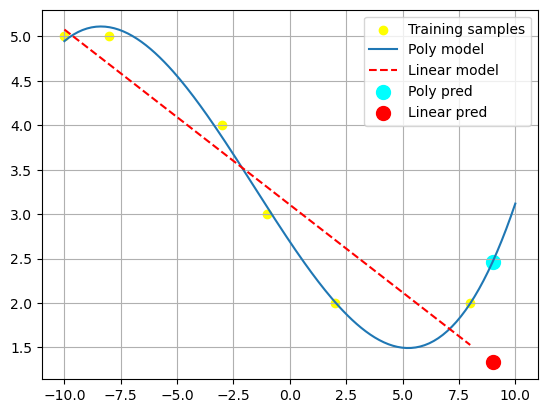

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# Tutorial 6 Q2 dataset
X = np.array([[-10], [-8], [-3], [-1], [2], [8]])
y = np.array([[5],   [5],  [4],  [3],  [2], [2]])

order = 3
P = polyTx(X, order)          # shape (N, 4): [1, x, x^2, x^3]
print('NOTICE: PolynomialFeatures column order may differ from handwritten version!')
print('P:\n', P)

# Fit
w_poly = solvePR(P, y)
print('Coefficients:', w_poly.ravel())

# Predict on new point
x_test = np.array([[9]])
P_test = polyTx(x_test, order)   # same order
y_pred_poly = P_test @ w_poly
print('Prediction at x=9:', y_pred_poly)

# Compare with linear model
bias    = np.ones((X.shape[0], 1))
X_      = np.hstack((bias, X))
w_lin   = solveLE(X_, y)
x_test_ = np.hstack((np.ones((1, 1)), x_test))
y_pred_lin = x_test_ @ w_lin
print('Linear pred at x=9:', y_pred_lin)

# Plot
x_plot = np.linspace(-10, 10, 200).reshape(-1, 1)
P_plot = polyTx(x_plot, order)
plt.scatter(X, y, color='yellow', label='Training samples')
plt.plot(x_plot, P_plot @ w_poly, label='Poly model')
plt.plot(X, X_ @ w_lin, color='red', linestyle='--', label='Linear model')
plt.scatter(9, y_pred_poly, color='cyan', s=100, label='Poly pred')
plt.scatter(9, y_pred_lin,  color='red',  s=100, label='Linear pred')
plt.grid(); plt.legend(); plt.show()

---
### Workflow 4 — Ridge Regression (Tutorial 6)

- **Primal** (N > M): $w^* = (P^\top P + \lambda I)^{-1} P^\top y$
- **Dual** (N < M): $w^* = P^\top (P P^\top + \lambda I)^{-1} y$

> Note: `lambda` is a Python keyword — use `lamb` or `lam`.

In [27]:
import numpy as np
from numpy.linalg import inv

X = np.array([[-10], [-8], [-3], [-1], [2], [8]])
y = np.array([[5],   [5],  [4],  [3],  [2], [2]])
P = polyTx(X, 3)

# --- Via tool (auto primal/dual) ---
lamb = 0.0001  # 'lambda' is a Python keyword
w_ridge = solvePR(P, y, ridge=True, lamb=lamb)
print('Ridge w (1dp):', np.around(w_ridge.T, decimals=1))

# --- Manually (primal, N > M) ---
reg_L    = lamb * np.eye(P.shape[1])   # lambda * I
w_primal = inv(P.T @ P + reg_L) @ P.T @ y
print('Manual primal w:', np.around(w_primal.T, decimals=4))

# --- Manually (dual, N < M) ---
X_under = np.array([[1, 0, 1], [1, -1, 1]])
y_under = np.array([[0], [1]])
P_under = polyTx(X_under, 3)
reg_L_d = lamb * np.eye(P_under.shape[0])
w_dual  = P_under.T @ inv(P_under @ P_under.T + reg_L_d) @ y_under
print('Dual w (1dp):', np.around(w_dual.T, decimals=1))

Ridge w (1dp): [[ 2.7 -0.4  0.   0. ]]
Manual primal w: [[ 2.6892 -0.3772  0.0134  0.0029]]
Dual w (1dp): [[ 0.   0.  -0.1  0.   0.  -0.1  0.   0.1 -0.1  0.   0.  -0.1  0.   0.1
  -0.1  0.  -0.1  0.1 -0.1  0. ]]


---
### Workflow 5 — Data Cleaning & Full Pipeline (Tutorial 2)

Use-case: **Pima Indians Diabetes** — physiologically impossible zeros = missing values.

In [28]:
import numpy as np
import pandas as pd

# Simulate Pima-style dataset (exam: df = pd.read_csv('pima-indians-diabetes.csv', header=None))
np.random.seed(7)
N_full = 100
raw = {
    1: np.where(np.random.rand(N_full) < 0.1, 0, np.random.randint(80, 200, N_full)).astype(float),
    2: np.where(np.random.rand(N_full) < 0.08, 0, np.random.randint(60, 120, N_full)).astype(float),
    3: np.where(np.random.rand(N_full) < 0.05, 0, np.random.randint(10, 50, N_full)).astype(float),
    4: np.where(np.random.rand(N_full) < 0.15, 0, np.random.randint(0, 800, N_full)).astype(float),
    5: np.where(np.random.rand(N_full) < 0.05, 0.0, np.random.uniform(18, 50, N_full)),
    8: np.random.randint(0, 2, N_full),
}
df_p = pd.DataFrame(raw)

print('=== Step 1: Check suspicious zeros ===')
print((df_p[[1, 2, 3, 4, 5]] == 0).sum())

print('\n=== Step 2: Replace zeros with NaN ===')
df_p[[1, 2, 3, 4, 5]] = df_p[[1, 2, 3, 4, 5]].replace(0, np.nan)
print(df_p.isnull().sum())
df_p.dropna(inplace=True)
print(f'Samples after cleaning: {len(df_p)}')

print('\n=== Step 3: Extract X, y ===')
X = np.array(df_p.iloc[:, :-1])
y = np.array(df_p.iloc[:, -1]).reshape(-1, 1)
N = X.shape[0]

print('\n=== Step 4: Add bias + train/test split ===')
X_b = np.hstack((np.ones((N, 1)), X))
split = int(0.8 * N)
X_train, X_test = X_b[:split], X_b[split:]
y_train, y_test = y[:split],   y[split:]

print('\n=== Step 5: Fit & Evaluate ===')
w = solveLE(X_train, y_train)
y_pred = X_test @ w
mse = np.mean((y_pred - y_test) ** 2)
print(f'Test MSE: {mse:.4f}')

=== Step 1: Check suspicious zeros ===
1     8
2     7
3     4
4    17
5     6
dtype: int64

=== Step 2: Replace zeros with NaN ===
1     8
2     7
3     4
4    17
5     6
8     0
dtype: int64
Samples after cleaning: 61

=== Step 3: Extract X, y ===

=== Step 4: Add bias + train/test split ===

=== Step 5: Fit & Evaluate ===
No exact sol, least square approx. 
w = [[ 1.61592994e+00]
 [-4.25116881e-03]
 [-1.39775960e-03]
 [ 2.20977320e-03]
 [ 1.69327105e-05]
 [-1.64742684e-02]]
Test MSE: 0.3085


---
### Workflow 6 — Binary Classification (Tutorial 6 Q4)

Use-case: classify as **+1 or −1** (e.g., COVID-19 positive/negative, spam/not-spam).

In [29]:
import numpy as np

# X manually biased (first column = 1)
X = np.array([[1, -1], [1, 0], [1, 0.5], [1, 0.3], [1, 0.8]])
y = np.array([[1], [1], [-1], [1], [-1]])

# Train linear regression classifier
w = solveLE(X, y)

# Predict: threshold raw output at 0 using np.sign()
X_test  = np.array([[1, -0.1], [1, 0.4]])
y_raw   = X_test @ w
y_class = np.sign(y_raw)        # → +1 or -1
print('Raw output:     ', y_raw.ravel())
print('Predicted class:', y_class.ravel())

No exact sol, least square approx. 
w = [[ 0.33333333]
 [-1.11111111]]
Raw output:      [ 0.44444444 -0.11111111]
Predicted class: [ 1. -1.]


---
### Workflow 7 — Multi-Class Classification with OneHotEncoder (Tutorial 6 Q5–Q6)

Use-case: classify **iris species** (or hand gestures) into 3+ categories.

Key rules:
- `encoder.fit_transform(y_train)` — fit on training labels only
- `encoder.inverse_transform(y_pred_raw)` — decode back to class labels
- Always use `polyTx(X_test, order)` with the **same** order as training

In [30]:
from sklearn.preprocessing import OneHotEncoder
import numpy as np

# --- Simple 3-class example (Tutorial 6 Q5) ---
# X already biased; Y has integer class labels 1/2/3
X = np.array([[1,-1], [1,0], [1,0.5], [1,0.3], [1,0.8]])
Y = np.array([[1], [1], [2], [3], [2]])

encoder = OneHotEncoder(sparse_output=False)
Y_onehot = encoder.fit_transform(Y)     # shape (N, n_classes)
print('One-hot Y:\n', Y_onehot)

W = solveLE(X, Y_onehot)               # weight matrix, shape (M, n_classes)

X_test  = np.array([[1, -0.1], [1, 0.4]])
y_raw   = X_test @ W
y_pred  = encoder.inverse_transform(y_raw)
print('Predicted classes:', y_pred.ravel())

One-hot Y:
 [[1. 0. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 1. 0.]]
No exact sol, least square approx. 
w = [[ 0.47798742  0.33333333  0.18867925]
 [-0.64989518  0.55555556  0.09433962]]
Predicted classes: [1 2]


In [31]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
import numpy as np

iris = load_iris()
X, y = iris.data, iris.target.reshape(-1, 1)

# --- Polynomial classification (Tutorial 6 Q6d) ---
# Split BEFORE polyTx (polynomial transform includes bias)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.26, random_state=0)

P_train = polyTx(X_train, order=2)
P_test  = polyTx(X_test,  order=2)     # transform only — do NOT refit

encoder = OneHotEncoder(sparse_output=False)
y_train_onehot = encoder.fit_transform(y_train)

W = solvePR(P_train, y_train_onehot)
y_pred = encoder.inverse_transform(P_test @ W)
accuracy = np.mean(y_pred.reshape(-1, 1) == y_test)
print(f'Poly Classification Accuracy: {accuracy:.2%}')

# --- Linear version for comparison (Tutorial 6 Q6c) ---
bias = np.ones((X.shape[0], 1))
X_b  = np.hstack((bias, X))
X_train_b, X_test_b, y_train, y_test = train_test_split(
    X_b, y, test_size=0.26, random_state=0)

encoder = OneHotEncoder(sparse_output=False)
y_train_onehot = encoder.fit_transform(y_train)

w_linear = solveLE(X_train_b, y_train_onehot)
y_pred_linear = encoder.inverse_transform(X_test_b @ w_linear)
correct = np.sum(y_pred_linear.reshape(-1, 1) == y_test)
print(f'Linear Classification: {correct} / {len(y_test)} correct')

Poly Classification Accuracy: 97.44%
No exact sol, least square approx. 
w = [[ 0.07441524  1.53840883 -0.61282406]
 [ 0.10300392 -0.0500674  -0.05293652]
 [ 0.21274711 -0.40080364  0.18805654]
 [-0.2510306   0.23622893  0.01480167]
 [-0.0365881  -0.50708077  0.54366887]]
Linear Classification: 30 / 39 correct


---
### Workflow 10 — Multi-Feature Polynomial Regression (Tutorial 6 Q3)

Use-case: apply polynomial expansion to **multi-dimensional** input — the resulting system is typically underdetermined (N < M), requiring the dual form or ridge regularization.

Key insight: with 3 input features at degree 3, `PolynomialFeatures` produces **20 columns** — far more than the 2 training samples. The system is underdetermined → use **dual form** or add ridge to stabilize primal.

In [35]:
import numpy as np
from numpy.linalg import inv

# Tutorial 6 Q3: 2D input → polynomial expansion creates many more features
X = np.array([[1,  0, 1],
              [1, -1, 1]])   # shape (2, 3): N=2 samples, 3 features
y = np.array([[0], [1]])

P = polyTx(X, 3)
print('X shape:', X.shape)     # (2, 3)
print('P shape:', P.shape)     # (2, 20) — 20 polynomial features from 3 inputs at degree 3
print('NOTICE: PolynomialFeatures column order may differ from handwritten version!')
print('System type:', det_checker(P))   # → "under" (N=2 < M=20)

# (c) Dual form — minimum-norm solution (no ridge)
w_dual = P.T @ inv(P @ P.T) @ y
print('\nw_dual (transposed):', w_dual.T)
print('Verify P @ w_dual == y:', (P @ w_dual).ravel())

# (d) Primal form with ridge — stabilizes when P^T P is near-singular
lamb   = 0.0001               # Note: 'lambda' is a Python keyword
reg_L  = lamb * np.eye(P.shape[1])
w_ridge = inv(P.T @ P + reg_L) @ P.T @ y
print('\nw_ridge (1dp):', np.around(w_ridge.T, decimals=1))
print('Close to dual?', np.allclose(np.around(w_dual, 1), np.around(w_ridge, 1)))

X shape: (2, 3)
P shape: (2, 20)
NOTICE: PolynomialFeatures column order may differ from handwritten version!
System type: under

w_dual (transposed): [[ 0.   0.  -0.1  0.   0.  -0.1  0.   0.1 -0.1  0.   0.  -0.1  0.   0.1
  -0.1  0.  -0.1  0.1 -0.1  0. ]]
Verify P @ w_dual == y: [0. 1.]

w_ridge (1dp): [[ 0.   0.  -0.1  0.   0.  -0.1  0.   0.1 -0.1  0.   0.  -0.1  0.   0.1
  -0.1  0.  -0.1  0.1 -0.1  0. ]]
Close to dual? True


---
## Part 6 — Tutorial 7 Extensions

Tutorial 7 introduces two new themes:

1. **Pearson's correlation as a feature-selection metric** (Q1) — rank features by `|r|` vs target.
2. **Polynomial orders 1–6 with train/test MSE, and the effect of ridge λ=1** (Q2) — a direct view into bias–variance.

Tools added below: **4.3 Pearson helpers**, **4.4 `polyorder_sweep`**, plus **Workflows 11–13** with worked Q1 / Q2a / Q2b examples.

### 4.3 Pearson Correlation — Feature Selection (Tut 7)

Definition (per EE2211 Tut 7):

$$
r = \frac{\frac{1}{N}\sum_{i=1}^{N}(a_i - \bar a)(b_i - \bar b)}{\sigma_a\,\sigma_b},\quad
\sigma_a = \sqrt{\tfrac{1}{N}\textstyle\sum_i (a_i - \bar a)^2}
$$

All sums use the **1/N** (biased) factor. The 1/N cancels in the ratio, so library functions using 1/(N−1) give the same r.

Helpers: `pearson_corr_manual(a, b)`, `feature_pearson_scores(X, y)`, `select_top_k_features(X, y, k)`.

Feature-selection rule: **rank by `|r|`** — sign doesn’t matter (both +1 and −1 are perfect linear relationships).


In [ ]:
import numpy as np

# =============================================================================
# SHAPE CONVENTION — applies to every feature-selection helper below
# =============================================================================
#   X : np.ndarray of shape (N, M)   -> N datapoints (rows), M features (cols)
#   y : np.ndarray of shape (N, 1)   -> target, one value per datapoint
#                                       (a 1-D (N,) vector is also accepted)
#
# WATCH OUT: the Tut 7 PDF tables list features as ROWS (3 features × 5 points).
# If you build a numpy array straight from the PDF, TRANSPOSE IT first:
#     X = data_from_pdf[:3].T   # (3, 5) -> (5, 3)
# Otherwise you'll compute "correlations across datapoints" instead of
# "correlation of each feature with y".
# =============================================================================

def _check_X_y(X, y, *, name):
    X = np.asarray(X)
    y = np.asarray(y).ravel()
    if X.ndim != 2:
        raise ValueError(f"{name}: X must be 2-D with shape (N, M); got shape {X.shape}")
    if X.shape[0] != y.size:
        raise ValueError(
            f"{name}: len(y)={y.size} must equal X.shape[0]={X.shape[0]}. "
            f"Did you forget to transpose? If the PDF listed features as rows, "
            f"use X = data[:M].T so rows=datapoints, cols=features."
        )
    return X, y


def pearson_corr_manual(a, b):
    """
    Pearson's r between two 1-D vectors, using the biased (1/N) estimator
    per the EE2211 Tut 7 definition.
    """
    a, b = np.asarray(a).ravel(), np.asarray(b).ravel()
    if a.size != b.size:
        raise ValueError(f"pearson_corr_manual: len(a)={a.size} != len(b)={b.size}")
    a_bar, b_bar = a.mean(), b.mean()
    cov = np.mean((a - a_bar) * (b - b_bar))
    sa  = np.sqrt(np.mean((a - a_bar) ** 2))
    sb  = np.sqrt(np.mean((b - b_bar) ** 2))
    return cov / (sa * sb)


def feature_pearson_scores(X, y):
    """|Pearson r| between each FEATURE COLUMN of X and target y. Shape (M,)."""
    X, y = _check_X_y(X, y, name='feature_pearson_scores')
    return np.array([abs(pearson_corr_manual(X[:, j], y)) for j in range(X.shape[1])])


def select_top_k_features(X, y, k):
    """
    Top-k feature selection by |Pearson r| with y.

    Returns
    -------
    X_selected : (N, k) array   columns of X indexed by top_idx
    top_idx    : (k,) int array column indices of X, sorted by |r| descending
    scores     : (M,) array     |r| for every column of X (unsorted)
    """
    X, y = _check_X_y(X, y, name='select_top_k_features')
    if not (1 <= k <= X.shape[1]):
        raise ValueError(f"select_top_k_features: k={k} out of range 1..{X.shape[1]}")
    scores  = feature_pearson_scores(X, y)
    top_idx = np.argsort(-scores)[:k]
    return X[:, top_idx], top_idx, scores


# Quick sanity check
a = np.array([1., 2., 3., 4., 5.])
b = np.array([2., 4., 6., 8., 9.])
print('pearson_corr_manual:', pearson_corr_manual(a, b))
print('np.corrcoef (same) :', np.corrcoef(a, b)[0, 1])


### 4.4 Polynomial Order Sweep — Train/Test MSE

Reusable helpers for Tut 7 Q2 (and exam-style "which order is best?" questions):

- `polyorder_sweep(Xtr, ytr, Xte, yte, orders, ridge=False, lamb=0)` → `(train_mse, test_mse, weights)`
- `plot_mse_vs_order(orders, train_mse, test_mse)` → quick plot

Internally uses **`polyTx`** for features and **`solvePR`** for weights, so it automatically selects primal (N > M) or dual (N ≤ M), with or without ridge.

In [ ]:
from sklearn.metrics import mean_squared_error  # alternative to np.mean((...)**2)

# =============================================================================
# SHAPE CONVENTION for polyorder_sweep
# =============================================================================
#   X_train, X_test : (N_tr, d) and (N_te, d)   rows = datapoints
#       For 1-D input with a single scalar feature (Tut 7 Q2), d=1 and you
#       MUST pass a column vector, e.g. np.array([[-10],[-8],...]) not
#       np.array([-10, -8, ...]).  PolynomialFeatures requires 2-D input.
#
#   y_train, y_test : (N_tr, 1) and (N_te, 1)   column vectors
#       A 1-D (N,) array also works, but the weight vector returned will then
#       be 1-D as well. For consistency with the rest of the cheatsheet, we
#       recommend reshaping targets to (N, 1).
#
#   orders : iterable[int]   polynomial degrees to try (e.g. range(1, 7))
#   ridge  : bool            add L2 regularization
#   lamb   : float           ridge strength (only read if ridge=True)
# =============================================================================

def _check_poly_inputs(X_train, y_train, X_test, y_test):
    X_train, X_test = np.asarray(X_train), np.asarray(X_test)
    y_train, y_test = np.asarray(y_train), np.asarray(y_test)
    for name, A in [('X_train', X_train), ('X_test', X_test)]:
        if A.ndim != 2:
            raise ValueError(
                f"{name} must be 2-D with shape (N, d); got shape {A.shape}. "
                f"For scalar input, reshape with .reshape(-1, 1)."
            )
    if X_train.shape[1] != X_test.shape[1]:
        raise ValueError(
            f"X_train has {X_train.shape[1]} feature(s), X_test has {X_test.shape[1]} — must match."
        )
    if y_train.shape[0] != X_train.shape[0]:
        raise ValueError(f"len(y_train)={y_train.shape[0]} != X_train.shape[0]={X_train.shape[0]}")
    if y_test.shape[0] != X_test.shape[0]:
        raise ValueError(f"len(y_test)={y_test.shape[0]} != X_test.shape[0]={X_test.shape[0]}")
    return X_train, y_train, X_test, y_test


def polyorder_sweep(X_train, y_train, X_test, y_test,
                    orders=range(1, 7), ridge=False, lamb=0.0):
    """
    Fit polynomial regression at each order in `orders` and record train/test MSE.

    Parameters
    ----------
    X_train : (N_tr, d) array  rows = training datapoints (d=1 for Tut 7 Q2)
    y_train : (N_tr, 1) array  training targets (column vector preferred)
    X_test  : (N_te, d) array  rows = test datapoints
    y_test  : (N_te, 1) array  test targets
    orders  : iterable[int]    polynomial degrees, e.g. range(1, 7)
    ridge   : bool             if True, apply ridge (L2) regularization
    lamb    : float            ridge strength (ignored when ridge=False)

    Returns
    -------
    train_mse : (len(orders),) array
    test_mse  : (len(orders),) array
    weights   : list of weight vectors, one per order
                (shapes vary: (order+1, 1) for d=1, more for multi-feature X)

    Notes
    -----
    Uses `polyTx` (PolynomialFeatures) for features and `solvePR` (auto
    primal/dual) for weights — so it picks the right form automatically when
    the polynomial expansion makes the system over- or under-determined.
    """
    X_train, y_train, X_test, y_test = _check_poly_inputs(X_train, y_train, X_test, y_test)
    orders = list(orders)
    train_mse, test_mse, weights = [], [], []
    for o in orders:
        P_tr = polyTx(X_train, o)
        P_te = polyTx(X_test,  o)
        w = solvePR(P_tr, y_train, ridge=ridge, lamb=lamb)
        train_mse.append(np.mean((P_tr @ w - y_train) ** 2))
        test_mse .append(np.mean((P_te @ w - y_test ) ** 2))
        weights.append(w)
    return np.array(train_mse), np.array(test_mse), weights


def plot_mse_vs_order(orders, train_mse, test_mse, title='Train vs Test MSE'):
    """
    Quick-look chart of train / test MSE across polynomial orders.

    Parameters
    ----------
    orders    : iterable[int]  x-axis (polynomial degrees)
    train_mse : array-like     y-values for the Train MSE line
    test_mse  : array-like     y-values for the Test  MSE line
    title     : str            plot title
    """
    plt.figure()
    plt.plot(list(orders), train_mse, 'o-', label='Train MSE')
    plt.plot(list(orders), test_mse,  's-', label='Test MSE')
    plt.xlabel('Polynomial order'); plt.ylabel('MSE')
    plt.title(title); plt.legend(); plt.grid(); plt.show()


# Smoke test on the Tut 6 dataset: order 3 should recover the solvePR result exactly.
X_s = np.array([[-10], [-8], [-3], [-1], [2], [8]])
y_s = np.array([[5],   [5],  [4],  [3],  [2], [2]])
tr, te, ws = polyorder_sweep(X_s, y_s, X_s, y_s, orders=[1, 2, 3], ridge=False)
print('Smoke train MSE:', np.round(tr, 4))
print('Smoke test  MSE:', np.round(te, 4))

# Shape-check demo: would raise if uncommented (1-D X not allowed).
# bad_X = np.array([-10, -8, -3, -1, 2, 8])        # 1-D — must be (N, 1)
# polyorder_sweep(bad_X, y_s, bad_X, y_s)          # ValueError with a hint

---
### Workflow 11 — Feature Selection via Pearson Correlation (Tut 7 Q1)

Use-case: given features × datapoints, rank features by **|Pearson r| vs target** and keep top-k.

**Exam data** (3 features × 5 datapoints):

|           | Datapoint 1 | Datapoint 2 | Datapoint 3 | Datapoint 4 | Datapoint 5 |
|-----------|------------|------------|------------|------------|------------|
| Feature 1 |  0.3510    |  2.1812    |  0.2415    | -0.1096    |  0.1544    |
| Feature 2 |  1.1796    |  2.1068    |  1.7753    |  1.2747    |  2.0851    |
| Feature 3 | -0.9852    |  1.3766    | -1.3244    | -0.6316    | -0.8320    |
| Target y  |  0.2758    |  1.4392    | -0.4611    |  0.6154    |  1.0006    |

Steps: (1) stack features as columns of X, (2) compute `feature_pearson_scores(X, y)`, (3) pick top-k via `select_top_k_features(X, y, k)`.


In [ ]:
# --- Tutorial 7 Q1 — Pearson correlation feature selection ---
# Table from PDF: rows = features, columns = 5 datapoints
data = np.array([
    [ 0.3510,  2.1812,  0.2415, -0.1096,  0.1544],   # Feature 1
    [ 1.1796,  2.1068,  1.7753,  1.2747,  2.0851],   # Feature 2
    [-0.9852,  1.3766, -1.3244, -0.6316, -0.8320],   # Feature 3
    [ 0.2758,  1.4392, -0.4611,  0.6154,  1.0006],   # Target y
])
X = data[:3].T                # (5, 3) — rows = datapoints, cols = features
y = data[ 3].reshape(-1, 1)   # (5, 1)

# |r| scores per feature
scores = feature_pearson_scores(X, y)
for i, s in enumerate(scores, start=1):
    r_signed = pearson_corr_manual(X[:, i-1], y)
    print(f'Feature {i}: r = {r_signed:+.4f}   |r| = {s:.4f}')

# Top-2 selection
X_sel, top_idx, _ = select_top_k_features(X, y, k=2)
print('\nTop-2 feature indices (0-based):', top_idx)
print('=> Features', (top_idx + 1).tolist(), 'are the answer to Q1.')
print('Selected X shape:', X_sel.shape)


---
### Workflow 12 — Polynomial Order Sweep (Tut 7 Q2a, no regularization)

Use-case: fit polynomial orders 1–6 to a small noisy 1D dataset; plot **train** and **test** MSE; identify under/overfitting.

**Training: 6 points, Test: 10 points** (Tut 7 Q2 — underlying generator = quadratic + noise).

Expectations:
- **Train MSE** decreases monotonically with order; at order ≥ 5 the model can *interpolate* 6 training points → train MSE ≈ 0.
- **Test MSE** is U-shaped — minimized near the true order (2), then explodes as overfitting kicks in.

The hint in the question ("quadratic + noise") is the ground truth. Use it to sanity-check your best-test-order.

In [ ]:
# --- Tutorial 7 Q2 datasets (verbatim from PDF) ---
# Training: 6 points (underlying = quadratic + noise)
X_train_tut7 = np.array([[-10], [-8], [-3], [-1], [2], [7]])
y_train_tut7 = np.array([[4.18], [2.42], [0.22], [0.12], [0.25], [3.09]])

# Test: 10 "clean" points. PDF also lists a trailing {x=-9}->{y=-6} outlier; include below if required.
X_test_tut7  = np.array([[-9], [-7], [-5], [-4], [-2], [1], [4], [5], [6], [9]])
y_test_tut7  = np.array([[3.0], [1.81], [0.80], [0.25], [-0.19], [0.4], [1.24], [1.68], [2.32], [5.05]])

# --- Optional: include the trailing outlier from the PDF ({x=-9, y=-6}) ---
# X_test_tut7 = np.vstack([X_test_tut7, [[-9]]])
# y_test_tut7 = np.vstack([y_test_tut7, [[-6.0]]])

orders = range(1, 7)
train_mse, test_mse, _ = polyorder_sweep(
    X_train_tut7, y_train_tut7, X_test_tut7, y_test_tut7,
    orders=orders, ridge=False)

print(f'{"order":>5}  {"train MSE":>10}  {"test MSE":>10}')
for o, tr, te in zip(orders, train_mse, test_mse):
    print(f'{o:>5}  {tr:>10.4f}  {te:>10.4f}')

print('\nBest order (train):', list(orders)[np.argmin(train_mse)])
print('Best order (test) :', list(orders)[np.argmin(test_mse)])

plot_mse_vs_order(orders, train_mse, test_mse,
                  title='Tut 7 Q2(a) — MSE vs polynomial order (no ridge)')

# Expected narrative:
# - Train MSE monotonically decreases with order (more capacity -> can overfit 6 points).
# - Order 5 interpolates the training set exactly -> train MSE = 0.
# - Test MSE minimized near order 2 (matches the quadratic ground truth).
# - Higher orders explode on test -> classic overfitting signature.

---
### Workflow 13 — Ridge Sweep Comparison (Tut 7 Q2b, λ=1)

Same order sweep, now with **ridge λ=1**. Compare against Q2(a):

- Training MSE **no longer hits 0** at high orders — regularization pulls coefficients toward 0 (adds bias).
- Test MSE at high orders is **much smaller** — ridge controls variance, prevents overfit.
- Curves flatten across orders → less bias–variance swing; choice of order matters less.

Rule of thumb: if the best-order-without-ridge wildly overfits, try ridge before chasing a lower polynomial degree.

In [ ]:
# Repeat the sweep with ridge lambda = 1 on the SAME train/test split
orders = range(1, 7)
tr_noreg, te_noreg, _ = polyorder_sweep(
    X_train_tut7, y_train_tut7, X_test_tut7, y_test_tut7,
    orders=orders, ridge=False)
tr_ridge, te_ridge, _ = polyorder_sweep(
    X_train_tut7, y_train_tut7, X_test_tut7, y_test_tut7,
    orders=orders, ridge=True, lamb=1.0)

print(f'{"order":>5} | {"no-reg train":>12} {"no-reg test":>12} | {"ridge train":>12} {"ridge test":>12}')
for o, a, b, c, d in zip(orders, tr_noreg, te_noreg, tr_ridge, te_ridge):
    print(f'{o:>5} | {a:>12.4f} {b:>12.4f} | {c:>12.4f} {d:>12.4f}')

# Overlay plot
plt.figure(figsize=(8, 5))
ord_list = list(orders)
plt.plot(ord_list, tr_noreg, 'o-',  label='Train (no reg)')
plt.plot(ord_list, te_noreg, 's-',  label='Test  (no reg)')
plt.plot(ord_list, tr_ridge, 'o--', label='Train (ridge λ=1)')
plt.plot(ord_list, te_ridge, 's--', label='Test  (ridge λ=1)')
plt.xlabel('Polynomial order'); plt.ylabel('MSE')
plt.title('Tut 7 Q2 — No-reg vs Ridge λ=1')
plt.legend(); plt.grid(); plt.show()

# Observation:
# - No ridge: train MSE drops toward 0 as order rises (overfit);
#   test MSE explodes at high orders.
# - Ridge λ=1: train MSE no longer hits 0 (bias added), but test MSE stays tame.
#   Curves flatten -> regularization trades a little bias for a lot of variance reduction.


### 4.5 Gradient Descent — reusable loop + key identities (Tut 8)

**Update rule**: $\mathbf{w}^{(t+1)} = \mathbf{w}^{(t)} - \eta\,\nabla_{\mathbf{w}} C(\mathbf{w}^{(t)})$.

**Core identity** (used in every Tut 8 derivation): for any input $\mathbf{x}$,
$$\nabla_{\mathbf{w}}(\mathbf{x}^{\top}\mathbf{w}) = \mathbf{x}.$$

Combined with the chain rule this is all you need to hand-derive $\nabla_{\mathbf{w}} C$ for the
standard (linear / sigmoid / ReLU / exp) activations.

**Learning-rate intuition** (confirmed experimentally in Tut 8 Q2):
- too small → barely moves within the iteration budget
- just right → smooth, monotone decrease
- too large → overshoots the minimum, oscillates, diverges to NaN

**Three flavours below**: vectorized (multi-dim w), scalar 1D, and scalar 2D — pick whichever fits the problem.

In [ ]:
# --- Reusable gradient-descent loop ---
# grad_fn(w) -> (cost_scalar, gradient_vector)
def gradient_descent(grad_fn, w0, lr, n_iters, record_every=1):
    """Vanilla GD. Returns final w and a cost history.

    grad_fn(w) must return (cost, gradient) with gradient.shape == w0.shape.
    """
    w = np.array(w0, dtype=float).copy()
    cost_hist = np.zeros(n_iters // record_every)
    for t in range(n_iters):
        cost, g = grad_fn(w)
        if t % record_every == 0:
            cost_hist[t // record_every] = cost
        w = w - lr * g
    return w, cost_hist


# --- Exponential model helper from Tut 8 Q2 ---
# f(x, w) = exp(-x^T w), square loss; gradient = -2 * (pred - y) * pred @ X
def exp_cost_gradient(X, w, y):
    """Forward + cost + gradient for exp(-x^T w) under square loss."""
    pred_y = np.exp(-X @ w)
    cost   = np.sum((pred_y - y) ** 2)
    grad   = -2 * (pred_y - y) * pred_y @ X
    return pred_y, cost, grad


# --- Smoke test: GD on f(x) = x^4 (Tut 8 Q1: x0=2, lr=0.1 -> x1 = -1.2) ---
def x4_grad_fn(w):
    return float(w[0] ** 4), 4 * w[0] ** 3 * np.ones_like(w)

w_final, hist = gradient_descent(x4_grad_fn, w0=np.array([2.0]), lr=0.1, n_iters=7)
print('Q1 check — first 7 iterates of x^4 with lr=0.1 (should oscillate/diverge):')
# reconstruct iterate path for visibility
x, path = 2.0, [2.0]
for _ in range(6):
    x = x - 0.1 * 4 * x**3
    path.append(round(x, 4))
print(path)


In [ ]:
# --- 1D scalar gradient descent (from A3 — simpler than vectorised version) ---
def gd_1d(grad_fn, x0, lr, num_iters):
    """1D GD: returns trajectory array of length num_iters."""
    x = float(x0)
    traj = np.empty(num_iters)
    for i in range(num_iters):
        x = x - lr * grad_fn(x)
        traj[i] = x
    return traj

# --- 2D scalar gradient descent (from A3 Task C) ---
def gd_2d(grad_fn, u0, v0, lr, num_iters):
    """2D GD: grad_fn(u,v) -> (du, dv). Returns (u_traj, v_traj)."""
    u, v = float(u0), float(v0)
    ut, vt = np.empty(num_iters), np.empty(num_iters)
    for i in range(num_iters):
        gu, gv = grad_fn(u, v)
        u, v = u - lr * gu, v - lr * gv
        ut[i], vt[i] = u, v
    return ut, vt


# ── Quick demo: Tut 8 Q1 — f(x)=x^4, x0=2, lr=0.1, one step ──
df_x4 = lambda x: 4 * x**3
traj = gd_1d(df_x4, x0=2.0, lr=0.1, num_iters=1)
print(f'Q1: x after 1 iter = {traj[0]}')  # 2 - 0.1*4*8 = 2 - 3.2 = -1.2


# ── LR sensitivity analysis (A3 Task A pattern) ──
# f(x)=(x-3)^2+5, x0=10
f_A  = lambda x: (x - 3)**2 + 5
df_A = lambda x: 2 * (x - 3)
lr_list   = [0.001, 0.1, 0.5, 0.9, 1.0, 1.1]
num_iters = 100

trajs   = {lr: gd_1d(df_A, 10.0, lr, num_iters) for lr in lr_list}
final_f = {lr: float(f_A(trajs[lr][-1])) for lr in lr_list}

diverging_lrs = sorted(lr for lr in lr_list if abs(trajs[lr][-1]) > 1e6)
converged_lrs = sorted(lr for lr in lr_list if final_f[lr] < 5.1)  # near min=5
print(f'Diverging LRs : {diverging_lrs}')
print(f'Converged LRs : {converged_lrs}')


# ── Multi-basin detection (A3 Task B pattern) ──
# f(x)=x^4-8x^2+x+10  — two local minima (left & right)
f_B  = lambda x: x**4 - 8*x**2 + x + 10
df_B = lambda x: 4*x**3 - 16*x + 1
inits = [-3.0, -1.0, 0.0, 1.0, 3.0]

final_x = {}
final_fB = {}
for x0 in inits:
    t = gd_1d(df_B, x0, lr=0.01, num_iters=5000)
    final_x[x0]  = float(t[-1])
    final_fB[x0] = float(f_B(t[-1]))

left_basin  = sorted(x0 for x0 in inits if final_x[x0] < 0)
right_basin = sorted(x0 for x0 in inits if final_x[x0] >= 0)
best_f = round(min(final_fB.values()), 2)
print(f'Left-basin inits : {left_basin}')
print(f'Right-basin inits: {right_basin}')
print(f'Best f found      : {best_f}')


# ── 2D basin counting (A3 Task C pattern) ──
# f(u,v) = sin(u)cos(v) + 0.1(u^2+v^2)
f_C = lambda u, v: np.sin(u)*np.cos(v) + 0.1*(u**2 + v**2)
grad_C = lambda u, v: (np.cos(u)*np.cos(v) + 0.2*u,
                        -np.sin(u)*np.sin(v) + 0.2*v)
pairs = [[0.1,0.1], [2.0,2.0], [-2.0,1.0], [1.0,-2.0]]

final_f_C = {}
for p in pairs:
    ut, vt = gd_2d(grad_C, p[0], p[1], lr=0.05, num_iters=3000)
    final_f_C[str(p)] = float(f_C(ut[-1], vt[-1]))

rounded = {k: round(v, 1) for k, v in final_f_C.items()}
num_basins = len(set(rounded.values()))
print(f'Distinct basins found: {num_basins}  (rounded f values: {rounded})')

---
### Workflow 14 — Exponential Model via GD (Tut 8 Q2)

Fit $f(x, \mathbf{w}) = \exp(-\mathbf{x}^{\top}\mathbf{w})$ with squared error. Key preprocessing:
normalize both the input year and target expenditure to $(0, 1]$ before optimization — otherwise
$\exp(-\cdot)$ explodes and gradients blow up.


In [ ]:
# Full GD fit for Tut 8 Q2 — load, normalize, train, extrapolate.
def fit_exp_model(csv_path, lr=0.03, n_iters=200_000,
                  year_col='year', value_col='total_expenditure_on_education'):
    df   = pd.read_csv(csv_path)
    y_raw = df[value_col].to_numpy().astype(float)
    years = df[year_col].to_numpy().astype(float)

    max_y, max_yr = y_raw.max(), years.max()
    y = y_raw / max_y
    X = np.ones((len(y), 2))
    X[:, 1] = years / max_yr

    def grad_fn(w):
        _, c, g = exp_cost_gradient(X, w, y)
        return c, g

    w, hist = gradient_descent(grad_fn, np.zeros(2), lr=lr, n_iters=n_iters)
    return dict(w=w, cost_hist=hist, years=years, y_raw=y_raw,
                max_y=max_y, max_yr=max_yr)

def predict_exp_model(fit, year_array):
    X = np.ones((len(year_array), 2))
    X[:, 1] = np.asarray(year_array) / fit['max_yr']
    return np.exp(-X @ fit['w']) * fit['max_y']

# Usage sketch (uncomment when the CSV is available):
# fit = fit_exp_model('../data/Tutorial 2 supp government-expenditure-on-education.csv',
#                     lr=0.03, n_iters=200_000)
# ext_years = np.arange(1981, 2024)
# preds     = predict_exp_model(fit, ext_years)
# plt.scatter(fit['years'], fit['y_raw'], label='data')
# plt.plot(ext_years, preds, 'r-', label='fit'); plt.legend(); plt.show()


---
### 4.6 Gradient Cookbook (Tut 8 Q3–Q5)

Pattern: $C(\mathbf{w}) = \sum_i L\big(f(\mathbf{x}_i, \mathbf{w}),\, y_i\big)$.
Differentiate $L$ w.r.t. $f$, then $f$ w.r.t. $\mathbf{w}$ (chain rule), then apply
$\nabla_{\mathbf{w}}(\mathbf{x}_i^{\top}\mathbf{w}) = \mathbf{x}_i$.

| Model $f$ | Loss $L$ | $\nabla_{\mathbf{w}} C$ |
|---|---|---|
| $\exp(-\mathbf{x}^{\top}\mathbf{w})$ | $(f - y)^2$ | $-\sum 2(f_i - y_i)\,f_i\,\mathbf{x}_i$ |
| $\mathbf{x}^{\top}\mathbf{w}$ (linear) | $(f - y)^2$ | $\sum 2(f_i - y_i)\,\mathbf{x}_i$ |
| $\mathbf{x}^{\top}\mathbf{w}$ (linear) | $(f - y)^4$ | $\sum 4(f_i - y_i)^3\,\mathbf{x}_i$ |
| $\sigma(\mathbf{x}^{\top}\mathbf{w})$, logistic | $(f - y)^4$ | $\sum 4(f_i - y_i)^3\,\beta\sigma(\cdot)(1-\sigma(\cdot))\,\mathbf{x}_i$ |
| $\sigma(\mathbf{x}^{\top}\mathbf{w})=\max(0,\cdot)$ (ReLU) | $(f - y)^4$ | $\sum 4(f_i - y_i)^3\,\mathbf{x}_i\,\mathbb{1}[\mathbf{x}_i^{\top}\mathbf{w}>0]$ |

**Useful derivative facts**:
- Logistic $\sigma(a)=\tfrac{1}{1+e^{-\beta a}}$ has $\sigma'(a)=\beta\,\sigma(a)(1-\sigma(a))$.
- ReLU $\max(0,a)$ has $\sigma'(a)=\mathbb{1}[a>0]$ (measure-zero kink at $a=0$ ignored).
- $\nabla_{\mathbf{w}} \exp(-\mathbf{x}^{\top}\mathbf{w}) = -\exp(-\mathbf{x}^{\top}\mathbf{w})\,\mathbf{x} = -f\,\mathbf{x}$.

**Exam instinct**: every Tut 8 derivation collapses to
*(outer-loss derivative) × (activation derivative) × $\mathbf{x}_i$*.


### 4.7 Decision-Tree Tools (Tut 9)

**Classification metrics** at a node with class counts $\mathbf{n}=[n_1,\dots,n_K]$, $p_k=n_k/n$:
- Gini: $G = 1 - \sum p_k^2$
- Entropy (base 2): $H = -\sum p_k \log_2 p_k$
- Misclass: $M = 1 - \max p_k$
- Overall (after split) = $\sum_c \tfrac{n_c}{n}\,\text{metric}(c)$; gain = parent − overall.

**Regression metrics**: leaf MSE = variance of $y$ at the node; split MSE = sample-weighted mean of children's MSEs; sklearn picks the threshold midpoint that minimizes it.


In [ ]:
# --- Classification node metrics ---
def gini(counts):
    c = np.asarray(counts, dtype=float); n = c.sum()
    return 0.0 if n == 0 else float(1 - np.sum((c / n) ** 2))

def entropy(counts, base=2):
    c = np.asarray(counts, dtype=float); n = c.sum()
    if n == 0: return 0.0
    p = c[c > 0] / n
    return float(-np.sum(p * (np.log(p) / np.log(base))))

def misclass(counts):
    c = np.asarray(counts, dtype=float); n = c.sum()
    return 0.0 if n == 0 else float(1 - c.max() / n)

def weighted_children(*c_list):
    tot = sum(sum(c) for c in c_list)
    return {k: sum(sum(c) * fn(c) for c in c_list) / tot
            for k, fn in [('gini', gini), ('entropy', entropy), ('misclass', misclass)]}

def split_gain(parent, *children):
    return {f"{k}_gain": (gini if k == 'gini' else entropy if k == 'entropy' else misclass)(parent)
            - weighted_children(*children)[k]
            for k in ('gini', 'entropy', 'misclass')}

# --- Regression-tree MSE ---
def mse(y):
    y = np.asarray(y, dtype=float)
    return 0.0 if len(y) == 0 else float(np.mean((y - y.mean()) ** 2))

def regression_split(x, y, threshold):
    x, y = np.asarray(x, dtype=float), np.asarray(y, dtype=float)
    L, R = y[x <= threshold], y[x > threshold]
    return dict(threshold=float(threshold), root_mse=mse(y),
                left=dict(n=len(L), mean=float(L.mean()) if len(L) else np.nan, mse=mse(L)),
                right=dict(n=len(R), mean=float(R.mean()) if len(R) else np.nan, mse=mse(R)),
                weighted_mse=(len(L) * mse(L) + len(R) * mse(R)) / len(y))

def find_best_split(x, y):
    x = np.asarray(x, dtype=float)
    xs = np.sort(np.unique(x))
    cands = (xs[:-1] + xs[1:]) / 2          # midpoints between sorted unique x
    best = None
    for t in cands:
        r = regression_split(x, y, t)
        if best is None or r['weighted_mse'] < best['weighted_mse']:
            best = r
    return best

# --- Recursive regression tree (1-D x), matches sklearn DecisionTreeRegressor ---
def build_regression_tree(x, y, max_depth, min_samples=1, depth=0):
    x, y = np.asarray(x, dtype=float), np.asarray(y, dtype=float)
    node = dict(depth=depth, n=len(y), mean=float(y.mean()) if len(y) else np.nan,
                mse=mse(y), leaf=True)
    if depth >= max_depth or len(y) <= min_samples or np.unique(x).size < 2:
        return node
    b = find_best_split(x, y)
    if b is None or b['weighted_mse'] >= node['mse'] - 1e-12:
        return node
    m = x <= b['threshold']
    node.update(leaf=False, threshold=b['threshold'],
                left =build_regression_tree(x[m],  y[m],  max_depth, min_samples, depth + 1),
                right=build_regression_tree(x[~m], y[~m], max_depth, min_samples, depth + 1))
    return node

# --- Sklearn classification-tree wrapper (Q4 boilerplate) ---
def fit_classification_tree(X, y, max_depth=4, criterion='entropy',
                            test_size=0.2, random_state=0,
                            feature_names=None, class_names=None, plot=True):
    from sklearn.model_selection import train_test_split
    from sklearn.tree import DecisionTreeClassifier, plot_tree
    from sklearn.metrics import accuracy_score
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=test_size, random_state=random_state)
    clf = DecisionTreeClassifier(max_depth=max_depth, criterion=criterion,
                                 random_state=random_state).fit(X_tr, y_tr)
    train_acc = accuracy_score(y_tr, clf.predict(X_tr))
    test_acc  = accuracy_score(y_te, clf.predict(X_te))
    print(f"train acc = {train_acc:.4f}  test acc = {test_acc:.4f}")
    if plot:
        fig, ax = plt.subplots(figsize=(14, 8))
        plot_tree(clf, feature_names=feature_names, class_names=class_names,
                  filled=True, rounded=True, ax=ax); plt.show()
    return dict(clf=clf, train_acc=train_acc, test_acc=test_acc,
                X_train=X_tr, X_test=X_te, y_train=y_tr, y_test=y_te)

# Smoke tests
print('pure  [10,0,0]:', gini([10, 0, 0]),  entropy([10, 0, 0]),  misclass([10, 0, 0]))
print('50/50 [5,5]   :', gini([5, 5]),       entropy([5, 5]),       misclass([5, 5]))
print('var of [1..5] :', mse([1, 2, 3, 4, 5]))            # expect 2.0
print('best split    :', find_best_split([1, 2, 3, 4, 5, 6], [1, 1, 1, 5, 5, 5])['threshold'])  # expect 3.5


---
### Workflow 15 — Sklearn Decision Trees (Tut 9 Q3 / Q4)

```python
# Regression tree to depth 2 (e.g. California Housing — MedInc → MedHouseVal)
from sklearn.tree import DecisionTreeRegressor, plot_tree
reg = DecisionTreeRegressor(criterion='squared_error', max_depth=2, random_state=0)
reg.fit(X.reshape(-1, 1), y)
# Read tree structure: thresholds, leaf means, per-node MSE
t = reg.tree_
for i in range(t.node_count):
    is_leaf = t.children_left[i] == -1
    print(i, 'leaf' if is_leaf else f'feat<={t.threshold[i]:.4f}',
          'n=', t.n_node_samples[i], 'mean=', t.value[i,0,0], 'mse=', t.impurity[i])

# Classification tree (entropy, depth 4) — full 80/20 + plot in one helper
from sklearn.datasets import load_iris
iris = load_iris()
out = fit_classification_tree(iris.data, iris.target,
                              max_depth=4, criterion='entropy',
                              feature_names=iris.feature_names,
                              class_names=list(iris.target_names))
```

Key knobs: `criterion ∈ {'gini', 'entropy', 'log_loss'}` (classifier) or `{'squared_error', 'absolute_error'}` (regressor); `max_depth`, `min_samples_leaf`, `min_samples_split`, `random_state` for reproducibility.


---
## Part 7 — Tutorial 10: Cross-Validation, Metrics & ROC

Tutorial 10 introduces three new exam topics:
1. **K-fold cross-validation** — hyperparameter selection, count of classifiers trained
2. **Confusion matrix & classification metrics** — accuracy, precision, recall, F1, cost-sensitive
3. **ROC curve & AUC** — true/false positive rates, Gini coefficient

---
### 4.8 K-fold CV + Polynomial Sweep (Tut 10 Q6 / Past Paper Q7)

Key formula: **k candidates × k folds = k² classifiers trained total** (each candidate gets k models).

```python
make_folds(n, k)          # → list of (train_idx, val_idx) pairs
kfold_poly_sweep(...)     # → (tr_errs, va_errs) averaged over folds
```

**Count trained models**: 3 candidates × 5-fold = **15** classifiers (Tutorial 10 Q2 → C=15).

**Choosing hyperparameter**: pick the one with lowest **average validation error**; if tied, prefer
simpler model (lower order / fewer parameters).

In [ ]:
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from numpy.linalg import inv

# ── make_folds ──────────────────────────────────────────────────────────────
def make_folds(n, k=5):
    """k-fold split over n samples (no shuffle; call on pre-shuffled data)."""
    fold_size = n // k
    folds = []
    for f in range(k):
        val_start = f * fold_size
        val_end   = (f + 1) * fold_size if f < k - 1 else n
        val_idx   = np.arange(val_start, val_end)
        train_idx = np.concatenate([np.arange(0, val_start), np.arange(val_end, n)])
        folds.append((train_idx, val_idx))
    return folds

# ── error_rate (OHE multi-class) ─────────────────────────────────────────────
def error_rate(P, W, Y_ohe):
    """Misclassification rate: argmax(PW) vs argmax(Y_ohe)."""
    pred = np.argmax(P @ W, axis=1)
    true = np.argmax(Y_ohe, axis=1)
    return np.mean(pred != true)

# ── kfold_poly_sweep ─────────────────────────────────────────────────────────
def kfold_poly_sweep(X, Y_ohe, orders, folds, lam=0.0):
    """
    For each polynomial order, compute average train/val error across k folds.
    Returns (tr_errs, va_errs) — same length as orders.
    Handles singular matrices with np.nan for that fold.
    """
    tr_errs, va_errs = [], []
    for order in orders:
        fold_tr, fold_va = [], []
        poly = PolynomialFeatures(degree=order, include_bias=True)
        for tr_idx, va_idx in folds:
            P_tr = poly.fit_transform(X[tr_idx])
            P_va = poly.transform(X[va_idx])
            try:
                PtP = P_tr.T @ P_tr
                W   = inv(PtP + lam * np.eye(PtP.shape[0])) @ P_tr.T @ Y_ohe[tr_idx]
                fold_tr.append(error_rate(P_tr, W, Y_ohe[tr_idx]))
                fold_va.append(error_rate(P_va, W, Y_ohe[va_idx]))
            except np.linalg.LinAlgError:
                fold_tr.append(np.nan); fold_va.append(np.nan)
        tr_errs.append(np.nanmean(fold_tr))
        va_errs.append(np.nanmean(fold_va))
    return tr_errs, va_errs


---
### Workflow 16 — 5-Fold CV on Iris (Tut 10 Q6)

Use-case: find optimal polynomial order via cross-validation on a multi-class dataset.
**Data split**: 150 total → 25 test (held out) + 125 CV (5 folds × 25 val = 25 train per fold).

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import OneHotEncoder

iris = load_iris()
X_all, y_all = iris.data, iris.target
ohe   = OneHotEncoder(sparse_output=False)
Y_all = ohe.fit_transform(y_all.reshape(-1, 1))  # (150, 3)

np.random.seed(42)
perm     = np.random.permutation(150)
X_test, Y_test = X_all[perm[:25]],  Y_all[perm[:25]]
X_cv,   Y_cv   = X_all[perm[25:]],  Y_all[perm[25:]]

folds_iris = make_folds(len(X_cv), k=5)  # saved for future reuse

orders = list(range(1, 11))

# No regularization sweep
tr_no, va_no = kfold_poly_sweep(X_cv, Y_cv, orders, folds_iris, lam=0.0)
# With ridge sweep (handles singular matrix at high orders)
tr_r, va_r   = kfold_poly_sweep(X_cv, Y_cv, orders, folds_iris, lam=1e-3)

best_no  = orders[np.nanargmin(va_no)]
best_r   = orders[np.nanargmin(va_r)]
print(f'Best order (no reg): {best_no}   Best order (ridge): {best_r}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
ax1.plot(orders, tr_no, 'b-o', label='Train'); ax1.plot(orders, va_no, 'r-o', label='Val')
ax1.set_title('No Regularization'); ax1.set_xlabel('Order'); ax1.set_ylabel('Error rate')
ax1.legend(); ax1.grid(True)
ax2.plot(orders, tr_r, 'b-o', label='Train'); ax2.plot(orders, va_r, 'r-o', label='Val')
ax2.set_title('Ridge λ=1e-3'); ax2.set_xlabel('Order')
ax2.legend(); ax2.grid(True)
plt.suptitle('5-Fold CV — Polynomial Order Selection (Iris)'); plt.tight_layout(); plt.show()


---
### 4.9 Confusion Matrix & Classification Metrics (Tut 10 Q5 / Past Paper Q8)

**Binary layout** (positive class = class of interest):

|              | Predicted +  | Predicted −  |
|---|---|---|
| **Actual +** | TP           | FN           |
| **Actual −** | FP           | TN           |

Key metrics:
$$\text{Accuracy} = \frac{TP+TN}{TP+TN+FP+FN}, \quad
  \text{Precision} = \frac{TP}{TP+FP}, \quad
  \text{Recall} = \frac{TP}{TP+FN}$$

$$F_1 = \frac{2 \cdot \text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$$

**Cost-sensitive accuracy** (past paper Q8 pattern):  
If correct → 0 cost; if FP (spam → inbox) → $C_{n,s}$ penalty; if FN (non-spam → spam) → $C_{s,n}$:
$$\text{Cost} = C_{n,s} \cdot FP + C_{s,n} \cdot FN$$
Lower cost = better. Compare classifiers by plugging in the same cost matrix.

**Sum constraint** (fill-in-blank trick): each row sums to actual class total.  
e.g. if row "Spam" = [40, x] and total spam = 50 → x = 10.

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve

# ── Binary confusion matrix helper ───────────────────────────────────────────
def binary_cm(y_true, y_pred, pos=1):
    """Returns dict with TP, TN, FP, FN and derived metrics."""
    tp = np.sum((y_pred == pos) & (y_true == pos))
    tn = np.sum((y_pred != pos) & (y_true != pos))
    fp = np.sum((y_pred == pos) & (y_true != pos))
    fn = np.sum((y_pred != pos) & (y_true == pos))
    n  = tp + tn + fp + fn
    prec = tp / (tp + fp) if (tp + fp) else 0.0
    rec  = tp / (tp + fn) if (tp + fn) else 0.0
    f1   = 2*prec*rec / (prec+rec) if (prec+rec) else 0.0
    return dict(TP=tp, TN=tn, FP=fp, FN=fn,
                accuracy=(tp+tn)/n, precision=prec, recall=rec, f1=f1)

# ── Cost-sensitive comparison ─────────────────────────────────────────────────
def cost_sensitive(TP, TN, FP, FN, C_fp=1.0, C_fn=1.0):
    """Total cost = C_fp * FP + C_fn * FN  (C_correct = 0)."""
    return C_fp * FP + C_fn * FN

# ── Example: past-paper Q8 spam classifier ───────────────────────────────────
# Jack's confusion matrix (rows=actual, cols=predicted)
# Spam: [40 spam_pred, x not_spam_pred]   Not-spam: [15, 35]
# Total emails = 100; row sums must be consistent
# From table: Spam actual row sums to 40 + x.
# We know total = 100, not-spam = 15+35=50, so spam actual = 50 → x = 10.
TP_j, FN_j, FP_j, TN_j = 40, 10, 15, 35
metrics_jack = binary_cm.__wrapped__ if hasattr(binary_cm,'__wrapped__') else None
jack = dict(TP=TP_j, TN=TN_j, FP=FP_j, FN=FN_j)
print('Jack: total spam actual =', TP_j + FN_j, '| correctly classified =', TP_j + TN_j)

# David's confusion matrix: Spam [50, y], Not-spam [10, 25]; total=100 → y=50-50=0? 
# Spam actual = 50 (same dataset), so 50+y=50 → y=0
TP_d, FN_d, FP_d, TN_d = 50, 0, 10, 40
david = dict(TP=TP_d, TN=TN_d, FP=FP_d, FN=FN_d)
print('David: total spam actual =', TP_d + FN_d, '| correctly classified =', TP_d + TN_d)

# Cost comparison: customers hate non-spam in spam folder → C_fn high (penalise FN)
# "spam in inbox ok" → C_fp LOW, C_fn HIGH → need C_ns < C_sn
# Jack cost vs David cost with equal weights for illustration
C_fp, C_fn = 1, 5
print(f'Jack cost  = {cost_sensitive(**jack,  C_fp=C_fp, C_fn=C_fn)}')
print(f'David cost = {cost_sensitive(**david, C_fp=C_fp, C_fn=C_fn)}')


---
### Workflow 17 — Multi-class Confusion Matrix (sklearn)

Use-case: quickly build and read a multi-class confusion matrix; compute per-class metrics.

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Example: 3-class predictions (iris style)
y_true = np.array([0,0,0,1,1,1,2,2,2,0,1,2])
y_pred = np.array([0,0,1,1,1,2,2,2,2,1,1,2])

cm = confusion_matrix(y_true, y_pred)
print('Confusion matrix (rows=actual, cols=predicted):')
print(cm)
# cm[i, j] = number of samples with actual class i predicted as class j
# Diagonal = correct; off-diagonal = errors

print()
print(classification_report(y_true, y_pred, target_names=['class0','class1','class2']))
# precision / recall / f1-score per class; macro avg = unweighted mean; weighted avg weights by support


---
### 4.10 ROC Curve / AUC (Past Paper Q14)

**ROC curve**: True Positive Rate (recall) vs False Positive Rate as threshold varies.
- Perfect classifier → AUC = 1.0 (curve hugs top-left corner)
- Random classifier → AUC = 0.5 (diagonal line)
- AUC is always in [0, 1] (True for past paper Q14b)
- **Gini coefficient** = 2 × AUC − 1 ∈ [−1, 1]; higher Gini = better (True for Q14c)

```python
from sklearn.metrics import roc_curve, roc_auc_score
fpr, tpr, thresholds = roc_curve(y_true_binary, y_scores)
auc = roc_auc_score(y_true_binary, y_scores)
gini = 2 * auc - 1
```

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.datasets import load_iris
from sklearn.preprocessing import label_binarize

iris = load_iris()
X, y = iris.data, iris.target
# Binary case: class 2 vs rest (using raw feature as proxy score)
y_bin    = (y == 2).astype(int)
y_scores = X[:, 2]            # petal length correlates with class 2

fpr, tpr, thresholds = roc_curve(y_bin, y_scores)
auc   = roc_auc_score(y_bin, y_scores)
gini  = 2 * auc - 1

print(f'AUC  = {auc:.3f}')
print(f'Gini = {gini:.3f}')
print(f'AUC in [0,1]: {0 <= auc <= 1}')   # True

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'ROC (AUC={auc:.3f}, Gini={gini:.3f})')
plt.plot([0,1],[0,1],'k--', label='Random')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve'); plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()


---
## Part 8 — Tutorials 11–12: Neural Networks

Tutorial 12 introduces two key exam topics:
1. **Neural network forward pass** — matrix multiply + activation (ReLU / sigmoid); optional bias column prepend
2. **MLP classifier (sklearn)** — CV to select hidden layer size, then test evaluation

---
### 4.11 Activation Functions

| Function | Formula | Range | Notes |
|---|---|---|---|
| ReLU | $\max(0, x)$ | $[0, \infty)$ | most common hidden layer; no vanishing gradient for $x>0$ |
| Sigmoid | $\frac{1}{1+e^{-x}}$ | $(0, 1)$ | output layer for binary; vanishing gradient problem |
| Softmax | $\frac{e^{x_k}}{\sum_j e^{x_j}}$ | $(0,1)$, sums to 1 | output layer for multi-class |

**Key exam facts**:
- Activation functions **introduce non-linearity** — without them, a deep network collapses to a single linear layer
- ReLU / sigmoid are NOT applied only to output nodes (they're used in hidden layers too)
- CNNs use **sparse** connections (filters), not dense — CNNs are NOT fully connected

In [ ]:
import numpy as np

def relu(x):     return np.maximum(0, x)
def sigmoid(x):  return 1.0 / (1.0 + np.exp(-x.astype(float)))
def softmax(x):
    e = np.exp(x - x.max(axis=-1, keepdims=True))   # numerically stable
    return e / e.sum(axis=-1, keepdims=True)

# Quick sanity checks
print('relu(-1, 0, 2)  :', relu(np.array([-1, 0, 2])))
print('sigmoid(-2,0,2) :', np.round(sigmoid(np.array([-2, 0, 2])), 4))
print('softmax([1,2,3]):', np.round(softmax(np.array([1., 2., 3.])), 4))


---
### 4.12 Neural Network Forward Pass (Tut 12 Q3–Q4 / Exam fill-in-blank)

**Without bias** (Q3 pattern):
$$F_\mathbf{w}(\mathbf{X}) = f(f(\mathbf{X}W_1)W_2)$$

**With bias column prepend** (Q4 pattern):
$$F_\mathbf{w}(\mathbf{X}) = f\!\bigl([\mathbf{1},\,f([\mathbf{1},\,f(\mathbf{X}W_1)]W_2)]\,W_3\bigr)$$
where $[\mathbf{1}, H]$ = `np.hstack([np.ones((n,1)), H])` — appends a bias column.

**Dimension check**:
- $\mathbf{X}$: $(m \times d)$, $W_1$: $(d \times h)$ → $H_1 = f(\mathbf{X}W_1)$: $(m \times h)$
- With bias prepend: $[\mathbf{1}, H_1]$: $(m \times (h+1))$, so $W_2$ must be $((h+1) \times \cdot)$

**Exam tip**: ReLU → `max(0, x)` element-wise; just zero out negatives in the matrix.

In [ ]:
import numpy as np

# -- Pattern A: no bias (Tut 12 Q3) --
def forward_no_bias(X, weights, activation):
    H = X.copy()
    for W in weights:
        H = activation(H @ W)
    return H

# Example: 2-layer ReLU (Tutorial 12 Q3)
X  = np.array([[1, 1, 3.0], [1, 2, 2.5]])
W1 = np.array([[-1,0,1],[0,-1,0],[1,0,1]])
out_A = forward_no_bias(X, [W1, W1], relu)
print("Q3 output (ReLU, no bias):\n", np.round(out_A, 1))  # [[2,0,6],[2,0,5]]

# -- Pattern B: bias prepend on hidden outputs only (Tut 12 Q4) --
# Formula: F = f([1, f([1, f(XW1)]W2)]W3)
# No bias on raw input X; prepend ones column to each hidden output.
def forward_with_bias(X, weights, activation):
    H = activation(X @ weights[0])   # first layer: no bias on input
    for W in weights[1:]:
        H = activation(np.hstack([np.ones((H.shape[0],1)), H]) @ W)
    return H

# Example: 3-layer Sigmoid (Tutorial 12 Q4)
# Dims: X(2,3)@W1(3,3)->H(2,3); [1,H](2,4)@W2(4,3)->H(2,3); [1,H](2,4)@W3(4,3)->(2,3)
X2  = np.array([[1,2,1],[1,5,1]], dtype=float)
W1b = np.array([[-1,0,1],[0,-1,0],[1,0,-1]], dtype=float)      # (3,3)
W23 = np.array([[-1,0,1],[0,-1,0],[1,0,1],[1,-1,1]], dtype=float)  # (4,3)
out_B = forward_with_bias(X2, [W1b, W23, W23], sigmoid)
print("Q4 output (Sigmoid, with bias):\n", np.round(out_B, 4))
# Expected: [[0.5259,0.2243,0.8913],[0.5219,0.2319,0.8897]]


---
### Workflow 18 — MLP CV: Find Best Hidden Layer Size (Tut 12 Q5)

Use-case: sweep hidden layer width `Nhidd` 1–10 with 5-fold CV on training set; plot accuracy curves;
pick `Nhidd` with best validation accuracy; evaluate on test set.

**sklearn MLP key params**:
- `solver='lbfgs'` — L-BFGS optimizer; good for small datasets
- `alpha` — L2 regularization (default 1e-4); use `1e-5` for less regularization
- `hidden_layer_sizes=(n, n, n)` — 3 hidden layers each with n nodes
- `random_state=1` — reproducibility

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn import metrics

iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(
    iris.data, iris.target, test_size=0.20, random_state=0
)

# 5-fold CV on training set (120 samples, 24 per fold)
Idx = np.random.RandomState(seed=8).permutation(len(y_train))
acc_tr, acc_va = [], []

for Nhidd in range(1, 11):
    fold_tr, fold_va = [], []
    for k in range(5):
        N        = int(np.round((k + 1) * len(y_train) / 5))
        val_idx  = Idx[N - 24 : N]
        train_idx = np.setdiff1d(Idx, val_idx)
        clf = MLPClassifier(solver='lbfgs', alpha=1e-5,
                            hidden_layer_sizes=(Nhidd, Nhidd, Nhidd),
                            random_state=1, max_iter=500)
        clf.fit(X_train[train_idx], y_train[train_idx])
        fold_tr.append(metrics.accuracy_score(y_train[train_idx], clf.predict(X_train[train_idx])))
        fold_va.append(metrics.accuracy_score(y_train[val_idx],   clf.predict(X_train[val_idx])))
    acc_tr.append(np.mean(fold_tr)); acc_va.append(np.mean(fold_va))

best = np.argmax(acc_va) + 1
print(f'Best Nhidd = {best}  (val acc = {acc_va[best-1]:.3f})')

plt.figure(figsize=(8, 4))
plt.plot(range(1,11), acc_tr, 'b-o', label='Training')
plt.plot(range(1,11), acc_va, color='orange', marker='x', lw=2, label='Validation')
plt.xlabel('Hidden nodes per layer'); plt.ylabel('Accuracy')
plt.title('MLP CV — Training & Validation Accuracy'); plt.legend(); plt.grid(True); plt.show()

# Final test
clf_f = MLPClassifier(solver='lbfgs', alpha=1e-5,
                      hidden_layer_sizes=(best, best, best), random_state=1, max_iter=500)
clf_f.fit(X_train, y_train)
print(f'Test accuracy = {metrics.accuracy_score(y_test, clf_f.predict(X_test)):.3f}')


---
## Quick Reference Card

| Task | One-liner |
|---|---|
| System type | `det_checker(X)` → "even" / "over" / "under" |
| Check consistency | `matrix_rank(X)` vs `matrix_rank(np.append(X,y,axis=1))` |
| Auto-solve LE | `w = solveLE(X, y)` |
| Left pseudo-inv (N > M) | `w = inv(X.T @ X) @ X.T @ y` |
| Right pseudo-inv (N < M) | `w = X.T @ inv(X @ X.T) @ y` |
| Add bias column | `np.hstack((np.ones((N,1)), X))` |
| Polynomial features | `P = polyTx(X, order)` |
| Poly regression | `w = solvePR(P, y)` |
| Poly + ridge | `w = solvePR(P, y, ridge=True, lamb=0.0001)` |
| **Pearson r (manual 1/N)** | **`pearson_corr_manual(a, b)`** |
| **|r| per feature** | **`feature_pearson_scores(X, y)`** |
| **Top-k by |r|** | **`select_top_k_features(X, y, k)` → X_sel, idx, scores** |
| **Poly order sweep** | **`polyorder_sweep(Xtr, ytr, Xte, yte, orders, ridge, lamb)`** |
| **Plot MSE vs order** | **`plot_mse_vs_order(orders, train_mse, test_mse)`** |
| **GD — generic loop** | **`w, hist = gradient_descent(grad_fn, w0, lr, n_iters)`** |
| **GD — exp model grad** | **`pred, cost, grad = exp_cost_gradient(X, w, y)`** |
| **Update rule** | **`w = w - lr * grad`** |
| **Linear + sq-loss grad** | **`2 * (X @ w - y).T @ X` (or per-sample sum)** |
| **∇w(xᵀw) identity** | **`x`  (drops out of every chain-rule derivation)** |
| **Sigmoid derivative** | **`beta * sig * (1 - sig)`** |
| **ReLU derivative** | **`(a > 0).astype(float)`** |
| **Gini / Entropy / Misclass** | **`gini(counts)` / `entropy(counts)` / `misclass(counts)`** |
| **Children weighted metrics** | **`weighted_children(B, C)` → dict(gini, entropy, misclass)** |
| **Split gain (parent − overall)** | **`split_gain(parent, *children)`** |
| **Regression leaf MSE** | **`mse(y)` = variance of `y`** |
| **Single split (regression)** | **`regression_split(x, y, threshold)`** |
| **Best regression split** | **`find_best_split(x, y)` (sklearn-matching midpoints)** |
| **Manual regression tree (1-D)** | **`build_regression_tree(x, y, max_depth)`** |
| **Sklearn classification tree** | **`fit_classification_tree(X, y, max_depth, criterion)`** |
| Binary classification | `np.sign(X_test @ w)` |
| One-hot encode | `OneHotEncoder(sparse_output=False).fit_transform(y)` |
| Multi-class predict | `encoder.inverse_transform(X_test @ W)` |
| MSE | `np.mean((y_pred - y)**2)` or `mean_squared_error(y, y_pred)` |
| Rank of matrix | `matrix_rank(X)` |
| Standardize | `(X - X.mean(0)) / X.std(0)` |
| 1D → column vector | `x.reshape(-1, 1)` |
| Drop col → numpy | `np.array(df.drop('col', axis=1))` |
| Replace 0 with NaN | `df[cols].replace(0, np.nan)` |
| Filter by category | `df.loc[df['type'] == 'val']` |
| Gaussian P(a ≤ X ≤ b) | `stats.norm.cdf(b,mu,sig) - stats.norm.cdf(a,mu,sig)` |
| Augmented matrix | `np.append(X, y, axis=1)` |

**Tut 7 exam instinct**:
- "Top-2 features by correlation" → `select_top_k_features(X, y, 2)`.
- "MSE over orders 1–6" → `polyorder_sweep(...)`; train monotone↓, test U-shaped.
- "Add ridge λ=1, compare" → rerun with `ridge=True, lamb=1.0`; test curve stays tame.
**Tut 8 exam instinct**:
- "What's $x$ after one GD step?" → compute $f'(x_0)$, then $x_1 = x_0 - \eta f'(x_0)$.
- "Derive $\nabla_{\mathbf{w}} C$" → chain rule: outer loss' × activation' × $\mathbf{x}_i$. Drop $\nabla_{\mathbf{w}}(\mathbf{x}_i^{\top}\mathbf{w}) = \mathbf{x}_i$ at the end.
- "Compare learning rates" → too small stalls, too large diverges; plot cost-vs-iteration to diagnose.
- "Why normalize inputs for $\exp(-\mathbf{x}^{\top}\mathbf{w})$?" → tiny $\mathbf{w}$ changes blow up $f$; rescale year/target to $(0,1]$.

**Tut 9 exam instinct**:
- "Compute Gini / entropy / misclass at each node" → `node_metrics(counts)`; overall depth-1 metric = `weighted_children(*children)`.
- "MSE at threshold $x=t$" → `regression_split(x, y, t)['weighted_mse']`; compare with `mse(y)` for the root.
- "Fit regression tree to depth $d$" → either `build_regression_tree(x, y, max_depth=d)` (manual) or `DecisionTreeRegressor(max_depth=d).fit(X.reshape(-1, 1), y)`; numbers should match.
- "Iris classification tree" → `fit_classification_tree(X, y, max_depth=4, criterion='entropy')` returns clf + train/test acc + plot.


**Part 7 — CV, Metrics, ROC**
| Task | One-liner |
|---|---|
| Build k folds | `make_folds(n, k=5)` → list of (train_idx, val_idx) |
| CV poly sweep | `kfold_poly_sweep(X, Y_ohe, orders, folds, lam)` → (tr_errs, va_errs) |
| Count trained models | k candidates × k folds = k² total |
| Binary metrics | `binary_cm(y_true, y_pred)` → dict with TP/TN/FP/FN/accuracy/precision/recall/f1 |
| Cost-sensitive | `cost_sensitive(TP, TN, FP, FN, C_fp, C_fn)` → total penalty |
| Multi-class CM | `confusion_matrix(y_true, y_pred)` — rows=actual, cols=predicted |
| Full report | `classification_report(y_true, y_pred)` — per-class P/R/F1 |
| ROC + AUC | `roc_curve(y_bin, scores)`, `roc_auc_score(y_bin, scores)` |
| Gini coeff | `2 * AUC - 1` ∈ [−1, 1]; higher = better |
| Confusion matrix fill trick | row sum = actual class count; use to find unknowns |

**Part 8 — Neural Networks**
| Task | One-liner |
|---|---|
| ReLU | `relu(x) = np.maximum(0, x)` |
| Sigmoid | `sigmoid(x) = 1/(1+np.exp(-x))` |
| Softmax | `e=np.exp(x-x.max()); e/e.sum()` |
| Forward (no bias) | `forward_no_bias(X, [W1,W2,...], activation)` |
| Forward (bias) | `forward_with_bias(X, [W1,W2,...], activation)` — prepends 1s each layer |
| MLP CV | `MLPClassifier(solver='lbfgs', hidden_layer_sizes=(N,N,N))` + fold loop |
| Bias prepend | `np.hstack([np.ones((n,1)), H])` |
| Dim check | $X(m,d) @ W(d,h) → H(m,h)$; with bias: $W$ must be $(h+1, \cdot)$ |